# Munset — Approach A, Category 1
## FDM Active Acoustic Stimulation — Preprocessing Pipeline

**Project:** Munset — AI-Enabled In-Ear Acoustics for Early Osteoporosis Screening  
**University:** Umm Al-Qura University  
**Pipeline source:** HeadSonic (He et al., 2025) — adapted by project supervisor  

---

### Pipeline Steps
1. Mount Google Drive and locate session files for one patient (right ear only)
2. Load each `.oe` file and extract: inward mic, outward mic, IMU, bone accelerometer
3. Split the microphone recording into 500 ms windows (200 ms active + 300 ms silent)
4. Reject motion-contaminated windows using IMU-based MAD thresholding
5. Remove airborne sound leakage using the outward-facing microphone
6. Bandpass filter the cleaned mic signal to 16–20 kHz
7. Extract active-phase transmission features (per chirp band energy, attenuation, centroid)
8. Extract silent-phase decay features (decay slope, ringing duration)
9. Extract bone accelerometer features (20–3000 Hz)
10. Z-score normalise within participant and save results

**⚠️ Set `PATIENT_ID` in the Configuration cell before running anything.**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import struct
import tempfile
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io.wavfile import write as wav_write
from scipy.signal import butter, filtfilt, welch
from scipy.stats import linregress
from sklearn.decomposition import PCA
from IPython.display import display, Audio

warnings.filterwarnings('ignore')
print('✅ All libraries imported.')

✅ All libraries imported.


## Configuration
Change `PATIENT_ID` here before running. Everything else is derived automatically.

In [ ]:
# ================================================================
# CONFIGURATION  —  Only change PATIENT_ID
# ================================================================

# Patient1 = Jana's Aunt (osteoporosis - 3 sessions)
# Patient2 = Naba'a (healthy - 4 sessions)
# Patient3 = Remas's Aunt (osteoporosis - 2 sessions)
# Patient4 = Jana's Mother (healthy - 4 sessions)
# (x) Patient5 = Naba'a's Sister (healthy - 3 sessions) [Note: this patient no longer used]
# Patient6 = Dana's Grandmother1 (osteoporosis - 3 sessions)
# Patient7 = Dana's Grandmother2 (osteoporosis - 3 sessions)
PATIENT_ID = "Patient7"

# ---- Google Drive paths ----------------------------------------
DRIVE_ROOT     = "/content/drive/MyDrive/Munset/Data"
PATIENT_PATH   = os.path.join(DRIVE_ROOT, PATIENT_ID)
RIGHT_EAR_PATH = os.path.join(PATIENT_PATH, "Right_Ear")
RESULT_PATH    = os.path.join(PATIENT_PATH, "Result")
os.makedirs(RESULT_PATH, exist_ok=True)

# ---- Microphone constants --------------------------------------
FS_MIC         = 48000                    # Sampling rate (Hz)
WINDOW_SAMPLES = int(FS_MIC * 0.500)     # 24 000  — full 500 ms window
ACTIVE_SAMPLES = int(FS_MIC * 0.200)     #  9 600  — first 200 ms (speaker ON)
SILENT_SAMPLES = int(FS_MIC * 0.300)     # 14 400  — last  300 ms (speaker OFF)

# ---- Chirp band constants (Munset protocol) --------------------
CHIRP_START = 16000.0          # First chirp starts at 16 000 Hz
CHIRP_BW    = 200.0            # Each chirp is 200 Hz wide
N_CHIRPS    = 14               # 14 simultaneous FDM chirps
GUARD_BW    = 1200.0 / 13.0   # Guard band ≈ 92.31 Hz between consecutive chirps

# ---- Motion rejection ------------------------------------------
MAD_K = 3    # threshold = median + 3 × 1.4826 × MAD

# ---- Explicit false-onset window drop list -----------------
# Windows identified via diagnostic as containing no real
# chirp signal (false onset detections at recording start).
# Add new patients here after running the boundary diagnostic.
WINDOWS_TO_DROP = {
    'Patient1': [0],
    'Patient2': [0, 1, 2, 3, 4],
    'Patient3': [0, 1],
    'Patient4': [0, 1],
    'Patient5': [0, 1],
    'Patient6': [0, 1, 2],
    'Patient7': [],
}

# ---- Summary ---------------------------------------------------
print(f"Patient      : {PATIENT_ID}")
print(f"Input        : {RIGHT_EAR_PATH}")
print(f"Output       : {RESULT_PATH}")
print(f"FS_MIC       : {FS_MIC} Hz")
print(f"Window       : {WINDOW_SAMPLES} samples  ({WINDOW_SAMPLES/FS_MIC*1000:.0f} ms)")
print(f"Active phase : {ACTIVE_SAMPLES} samples  ({ACTIVE_SAMPLES/FS_MIC*1000:.0f} ms)")
print(f"Silent phase : {SILENT_SAMPLES} samples  ({SILENT_SAMPLES/FS_MIC*1000:.0f} ms)")
print(f"Chirp range  : {int(CHIRP_START)} – 20 000 Hz  |  {N_CHIRPS} bands × {int(CHIRP_BW)} Hz  |  guard ≈ {GUARD_BW:.2f} Hz")

Patient      : Patient7
Input        : /content/drive/MyDrive/Munset/Data/Patient7/Right_Ear
Output       : /content/drive/MyDrive/Munset/Data/Patient7/Result
FS_MIC       : 48000 Hz
Window       : 24000 samples  (500 ms)
Active phase : 9600 samples  (200 ms)
Silent phase : 14400 samples  (300 ms)
Chirp range  : 16000 – 20 000 Hz  |  14 bands × 200 Hz  |  guard ≈ 92.31 Hz


## OpenEarable Parsing Class
Copied directly from the official OpenEarable `.oe` file parsing notebook.

In [ ]:
# ================================================================
# OPENEARABLE PARSING CLASS
# Source: OpenEarable .oe File Parsing Notebook (v2, Nov 2024)
# ================================================================

LABELS = {
    "imu"         : ['acc.x', 'acc.y', 'acc.z',
                       'gyro.x', 'gyro.y', 'gyro.z',
                       'mag.x', 'mag.y', 'mag.z'],
    "barometer"   : ['barometer.temperature', 'barometer.pressure'],
    "ppg"         : ['ppg.red', 'ppg.ir', 'ppg.green', 'ppg.ambient'],
    "bone_acc"    : ['bone_acc.x', 'bone_acc.y', 'bone_acc.z'],
    "optical_temp": ['optical_temp'],
}

COLORS = {"ppg": ['red', 'darkred', 'green', 'gray']}


class SensorAccessor:
    def __init__(self, df: pd.DataFrame, labels: list):
        self._df   = df
        self._data = {}
        groups     = defaultdict(list)

        for label in labels:
            parts = label.split('.')
            if len(parts) == 2:
                group, field = parts
                if label in df:
                    groups[group].append(label)
            else:
                if label in df:
                    self._data[label] = df[label]

        for group, columns in groups.items():
            short_names = [lbl.split('.')[1] for lbl in columns]
            subdf = df[columns].copy()
            subdf.columns = short_names
            self._data[group] = subdf

        self._full_df = (
            pd.concat(self._data.values(), axis=1)
            if self._data else df
        )

    def __getitem__(self, key):
        return self._data.get(key, None)

    def __getattr__(self, name):
        if name in self._data:
            return self._data[name]
        if hasattr(self._full_df, name):
            return getattr(self._full_df, name)
        raise AttributeError(f"'SensorAccessor' has no attribute '{name}'")

    def __repr__(self):
        return repr(self._full_df)

    def to_dataframe(self):
        return self._full_df


class SensorDataset:
    SENSOR_SID = {
        "imu"        : 0,
        "barometer"  : 1,
        "microphone" : 2,
        "ppg"        : 4,
        "optical_temp": 6,
        "bone_acc"   : 7,
    }

    sensor_formats = {
        0: '<9f',   # imu
        1: '<2f',   # barometer
        4: '<4I',   # ppg
        6: '<f',    # optical_temp
        7: '<3h',   # bone_acc
    }

    def __init__(self, filename):
        self.filename    = filename
        self.data        = defaultdict(list)
        self.audio_stereo = None
        self.bone_sound  = None
        self.df          = pd.DataFrame()

        self.imu          = SensorAccessor(pd.DataFrame(columns=LABELS['imu']),          LABELS['imu'])
        self.barometer    = SensorAccessor(pd.DataFrame(columns=LABELS['barometer']),    LABELS['barometer'])
        self.ppg          = SensorAccessor(pd.DataFrame(columns=LABELS['ppg']),          LABELS['ppg'])
        self.bone_acc     = SensorAccessor(pd.DataFrame(columns=LABELS['bone_acc']),     LABELS['bone_acc'])
        self.optical_temp = SensorAccessor(pd.DataFrame(columns=LABELS['optical_temp']), LABELS['optical_temp'])

        self.parse()
        self._build_accessors()

    def parse(self):
        FILE_HEADER_FORMAT = '<HQ'
        FILE_HEADER_SIZE   = struct.calcsize(FILE_HEADER_FORMAT)
        mic_samples = []
        _sid = None

        with open(self.filename, 'rb') as f:
            version, timestamp = struct.unpack(
                FILE_HEADER_FORMAT, f.read(FILE_HEADER_SIZE)
            )
            print(f"  📂 {os.path.basename(self.filename)}  "
                  f"ver={version}  t0={timestamp}µs")

            while True:
                header = f.read(10)
                if len(header) < 10:
                    break
                sid, size, time = struct.unpack('<BBQ', header)
                if size > 192 or sid > 7:
                    if _sid is not None and _sid in self.data:
                        self.data[_sid].pop()
                    break
                _sid = sid
                data = f.read(size)
                if len(data) < size:
                    break
                timestamp_s = time / 1e6

                try:
                    if sid == self.SENSOR_SID['microphone']:
                        samples = struct.unpack('<96h', data)
                        mic_samples.extend(samples)
                    elif version < 2 and sid == self.SENSOR_SID['bone_acc']:
                        self.data[sid].append((timestamp_s, data))
                    elif sid in self.sensor_formats:
                        fmt           = self.sensor_formats[sid]
                        expected_size = struct.calcsize(fmt)
                        if size == expected_size:
                            values = struct.unpack(fmt, data)
                            self.data[sid].append((timestamp_s, values))
                        elif (size - 2) % expected_size == 0:
                            delta = struct.unpack('<H', data[-2:])[0] / 1e6
                            data  = data[:-2]
                            for n in range(len(data) // expected_size):
                                values = struct.unpack(
                                    fmt,
                                    data[n * expected_size: (n + 1) * expected_size]
                                )
                                self.data[sid].append(
                                    (timestamp_s + n * delta, values)
                                )
                        else:
                            continue
                    else:
                        continue
                except struct.error:
                    pass

        if mic_samples:
            mic_array = np.array(mic_samples, dtype=np.int16)
            # col-0 = inner mic, col-1 = outer mic
            self.audio_stereo = np.column_stack(
                (mic_array[1::2], mic_array[0::2])
            )

        # Legacy bone_acc handling (firmware < v2)
        if version < 2 and len(self.data[7]) > 0:
            all_samples   = []
            sample_counts = []
            for _, d in self.data[7]:
                n_per = len(d) // struct.calcsize('<3h')
                sample_counts.append(n_per)
                for i in range(n_per):
                    off    = i * struct.calcsize('<3h')
                    sample = struct.unpack('<3h', d[off: off + struct.calcsize('<3h')])
                    all_samples.append(sample)
            detailed_times = []
            for i in range(len(self.data[7]) - 1):
                cur_t  = self.data[7][i][0]
                nxt_t  = self.data[7][i + 1][0]
                n_samp = sample_counts[i]
                if n_samp > 0:
                    dt = (nxt_t - cur_t) / (n_samp + 1)
                    detailed_times.extend(
                        [cur_t + j * dt for j in range(n_samp)]
                    )
            self.data[7] = list(zip(detailed_times, all_samples))

    def _build_accessors(self):
        dfs = []
        for name, sid in self.SENSOR_SID.items():
            labels = LABELS.get(name, [])
            if sid in self.data and self.data[sid]:
                times, values = zip(*self.data[sid])
                df = pd.DataFrame(values, columns=labels)
                df['timestamp'] = times
                df.set_index('timestamp', inplace=True)
                df = df[~df.index.duplicated(keep='first')]
                dfs.append(df)
            else:
                df = pd.DataFrame(columns=labels)
            setattr(self, name, SensorAccessor(df, labels))

        if dfs:
            common_index = pd.Index([])
            for df in dfs:
                common_index = common_index.union(df.index)
            common_index = common_index.sort_values()
            self.df = pd.concat(
                [df.reindex(common_index) for df in dfs], axis=1
            )
        else:
            self.df = pd.DataFrame()

    def save_audio(self, path, sampling_rate=48000):
        if self.audio_stereo is None:
            print('❌ No microphone data to save.')
            return
        wav_write(path, sampling_rate, self.audio_stereo)
        print(f'✅ Audio saved → {path}')


print('✅ SensorDataset class ready.')

✅ SensorDataset class ready.


## Step 1 — Find Session Files

In [ ]:
# ================================================================
# Locate Session1.oe, Session2.oe, Session3.oe
# Continues gracefully if only 2 sessions exist.
# ================================================================

session_paths = []
for i in range(1, 5):
    p = os.path.join(RIGHT_EAR_PATH, f"Session{i}.oe")
    if os.path.isfile(p):
        session_paths.append(p)
        print(f"✅ Found  : Session{i}.oe")
    else:
        print(f"⚠️  Missing: Session{i}.oe — will be skipped")

if not session_paths:
    raise FileNotFoundError(
        f"No session files found in:\n  {RIGHT_EAR_PATH}\n"
        "Check that PATIENT_ID and the Drive folder structure are correct."
    )

print(f"\n→ Will process {len(session_paths)} session(s) for {PATIENT_ID}")

✅ Found  : Session1.oe
✅ Found  : Session2.oe
✅ Found  : Session3.oe
⚠️  Missing: Session4.oe — will be skipped

→ Will process 3 session(s) for Patient7


## Helper Functions
All signal processing functions used by the pipeline.

In [ ]:
# ================================================================
# STEPS 6–7 : Motion scoring and rejection
# ================================================================

def compute_motion_scores(acc_win, gyro_win):
    """
    Compute motion intensity for one 500 ms sample.

    Parameters
    ----------
    acc_win, gyro_win : pd.DataFrame  (columns: x, y, z)
        IMU slices aligned to this sample window.

    Returns
    -------
    acc_score  : float  — RMS of gravity-removed acceleration magnitude
    gyro_score : float  — RMS of gyroscope magnitude
    (nan, nan) if data is absent or too short.
    """
    if acc_win.empty or gyro_win.empty or len(acc_win) < 3 or len(gyro_win) < 3:
        return np.nan, np.nan

    ax = acc_win['x'].values.astype(float)
    ay = acc_win['y'].values.astype(float)
    az = acc_win['z'].values.astype(float)

    gx = gyro_win['x'].values.astype(float)
    gy = gyro_win['y'].values.astype(float)
    gz = gyro_win['z'].values.astype(float)

    # Accelerometer: 3-axis magnitude, remove static gravity, then RMS
    acc_mag    = np.sqrt(ax**2 + ay**2 + az**2)
    acc_motion = acc_mag - np.median(acc_mag)       # removes gravity component
    acc_score  = np.sqrt(np.mean(acc_motion**2))    # RMS = motion energy

    # Gyroscope: 3-axis magnitude, then RMS
    gyro_mag   = np.sqrt(gx**2 + gy**2 + gz**2)
    gyro_score = np.sqrt(np.mean(gyro_mag**2))

    return float(acc_score), float(gyro_score)


def mad_threshold(scores, k=MAD_K):
    """
    Compute a robust outlier threshold:  median + k * 1.4826 * MAD
    NaN values in `scores` are ignored.
    """
    vals = np.asarray([s for s in scores if not np.isnan(s)], dtype=float)
    if len(vals) == 0:
        return np.inf
    median = np.median(vals)
    mad    = np.median(np.abs(vals - median))
    return float(median + k * 1.4826 * mad)


# ================================================================
# STEP 8 : Airborne sound removal
# ================================================================

def remove_airborne(inward, outward):
    """
    Isolate the bone-conducted signal by subtracting scaled outward mic.

    The outward mic records mostly airborne / ambient sound.
    A leakage factor alpha is computed so that:
        bone_signal = inward - alpha * outward

    Applied separately to the 200 ms active and 300 ms silent sub-windows.

    Returns
    -------
    bone_signal : np.ndarray  — bone-dominant signal
    alpha       : float       — leakage scaling factor (diagnostic)
    """
    inward  = np.asarray(inward,  dtype=float)
    outward = np.asarray(outward, dtype=float)

    n       = min(len(inward), len(outward))
    inward  = inward[:n]
    outward = outward[:n]

    # Remove DC offset from both signals
    inward  = inward  - np.mean(inward)
    outward = outward - np.mean(outward)

    # Leakage factor: projection of inward onto outward
    alpha = np.dot(inward, outward) / (np.dot(outward, outward) + 1e-12)

    # Subtract airborne leakage
    bone_signal = inward - alpha * outward

    return bone_signal, float(alpha)


# ================================================================
# STEP 9 : Bandpass filters
# ================================================================

def bandpass_16_20k(x):
    """
    4th-order Butterworth bandpass filter: 16 000 – 20 000 Hz.
    Isolates the chirp transmission band in the microphone signal.
    Uses the global FS_MIC (48 000 Hz).
    """
    nyq  = FS_MIC / 2.0
    b, a = butter(4, [16000.0 / nyq, 20000.0 / nyq], btype='band')
    return filtfilt(b, a, x)


def bandpass_bone(x, fs_bone):
    """
    4th-order Butterworth bandpass filter: 20 – 3 000 Hz.
    Matches the bone accelerometer's usable frequency range.
    """
    nyq  = fs_bone / 2.0
    b, a = butter(4, [20.0 / nyq, 3000.0 / nyq], btype='band')
    return filtfilt(b, a, x)


# ================================================================
# STEP 10 : Active-phase features  (first 200 ms)
# ================================================================

def extract_active_features(x):
    """
    Extract transmission features from the 200 ms active phase.

    The signal has already been:
      - airborne-cleaned (Step 8)
      - bandpassed to 16–20 kHz (Step 9)

    Features
    --------
    chirp_01_energy … chirp_14_energy
        PSD energy integrated within each of the 14 chirp bands.
        Captures how well each sub-band is transmitted through skull/bone.

    attenuation_slope
        Slope of log(energy) vs. chirp centre frequency (linregress).
        Negative slope = high frequencies attenuated more (typical in denser bone).

    high_low_ratio
        Energy(chirps 8–14) / Energy(chirps 1–7).
        High-frequency preservation index.

    spectral_centroid
        Weighted mean frequency over the full 16–20 kHz PSD.
    """
    freqs, psd = welch(x, fs=FS_MIC, nperseg=min(2048, len(x)))
    psd = psd + 1e-12

    feats    = {}
    energies = []
    centers  = []

    for i in range(N_CHIRPS):
        f1 = CHIRP_START + i * (CHIRP_BW + GUARD_BW)  # chirp lower edge
        f2 = f1 + CHIRP_BW                             # chirp upper edge
        fc = (f1 + f2) / 2.0                           # centre frequency

        idx    = (freqs >= f1) & (freqs < f2)
        energy = float(np.sum(psd[idx]))

        feats[f"chirp_{i+1:02d}_energy"] = energy
        energies.append(energy)
        centers.append(fc)

    energies = np.array(energies)
    centers  = np.array(centers)

    slope_res = linregress(centers, np.log(energies + 1e-12))
    feats['attenuation_slope'] = float(slope_res.slope)

    feats['high_low_ratio'] = float(
        np.sum(energies[7:]) / (np.sum(energies[:7]) + 1e-12)
    )

    feats['spectral_centroid'] = float(np.sum(freqs * psd) / np.sum(psd))

    return feats


# ================================================================
# STEP 11 : Silent-phase features  (last 300 ms)
# ================================================================

def extract_silent_features(x):
    """
    Extract decay / damping features from the 300 ms silent phase.

    The speaker is OFF during this window. The signal is the bone's
    residual ringing after the chirp stops.

    Features
    --------
    decay_slope
        Slope of log(envelope) vs. time for samples above 5% of peak.
        More negative = faster decay (less dense bone rings longer).

    ringing_duration_ms
        Duration (ms) for which the envelope stays above 5% of peak.

    silent_high_low_ratio
        PSD energy in 18–20 kHz vs 16–18 kHz during silence.

    silent_spectral_centroid
        Weighted mean frequency over the 16–20 kHz PSD during silence.
    """
    feats = {}

    env     = np.abs(x)
    max_env = np.max(env)

    if max_env < 1e-12:
        feats['decay_slope']         = np.nan
        feats['ringing_duration_ms'] = 0.0
    else:
        env_norm = env / max_env
        t        = np.arange(len(env_norm)) / float(FS_MIC)
        valid    = env_norm > 0.05

        if np.sum(valid) > 5:
            slope_res = linregress(t[valid], np.log(env_norm[valid] + 1e-12))
            feats['decay_slope']         = float(slope_res.slope)
            feats['ringing_duration_ms'] = float(np.sum(valid) / FS_MIC * 1000.0)
        else:
            feats['decay_slope']         = np.nan
            feats['ringing_duration_ms'] = 0.0

    freqs, psd = welch(x, fs=FS_MIC, nperseg=min(2048, len(x)))
    psd = psd + 1e-12

    low  = float(np.sum(psd[(freqs >= 16000) & (freqs <  18000)]))
    high = float(np.sum(psd[(freqs >= 18000) & (freqs <= 20000)]))

    feats['silent_high_low_ratio']    = high / (low + 1e-12)
    feats['silent_spectral_centroid'] = float(np.sum(freqs * psd) / np.sum(psd))

    return feats


# ================================================================
# STEPS 12–13 : Bone accelerometer features
# ================================================================

def extract_bone_features(bone_win, fs_bone):
    """
    Extract bone-conducted vibration features from one 500 ms window.

    The bone accelerometer operates at ≈ 6 400 Hz and is sensitive
    up to 3 200 Hz. Only the 20–3 000 Hz band is used.

    Returns NaN for all features if the window has fewer than 10 samples.

    Features
    --------
    bone_rms              — overall vibration energy
    bone_dom_freq         — dominant frequency of the bone response
    bone_spectral_centroid— weighted mean frequency
    bone_low_power        — PSD energy in  20 – 300 Hz
    bone_mid_power        — PSD energy in 300 – 1 000 Hz
    bone_high_power       — PSD energy in 1 000 – 3 000 Hz
    bone_high_low_ratio   — bone_high_power / bone_low_power
    """
    nan_feats = {k: np.nan for k in [
        'bone_rms', 'bone_dom_freq', 'bone_spectral_centroid',
        'bone_low_power', 'bone_mid_power', 'bone_high_power',
        'bone_high_low_ratio'
    ]}

    if bone_win.empty or len(bone_win) < 10:
        return nan_feats

    bx = bone_win['x'].values.astype(float)
    by = bone_win['y'].values.astype(float)
    bz = bone_win['z'].values.astype(float)

    # 3-axis magnitude, then remove DC
    bone_mag = np.sqrt(bx**2 + by**2 + bz**2)
    bone_mag = bone_mag - np.mean(bone_mag)

    # Bandpass 20–3 000 Hz
    try:
        bone_filt = bandpass_bone(bone_mag, fs_bone)
    except Exception:
        return nan_feats

    nperseg    = min(1024, len(bone_filt))
    freqs, psd = welch(bone_filt, fs=fs_bone, nperseg=nperseg)
    psd        = psd + 1e-12

    feats = {}
    feats['bone_rms']               = float(np.sqrt(np.mean(bone_filt**2)))
    feats['bone_dom_freq']          = float(freqs[np.argmax(psd)])
    feats['bone_spectral_centroid'] = float(np.sum(freqs * psd) / np.sum(psd))
    feats['bone_low_power']         = float(np.sum(psd[(freqs >= 20)   & (freqs <  300)]))
    feats['bone_mid_power']         = float(np.sum(psd[(freqs >= 300)  & (freqs < 1000)]))
    feats['bone_high_power']        = float(np.sum(psd[(freqs >= 1000) & (freqs <= 3000)]))
    feats['bone_high_low_ratio']    = feats['bone_high_power'] / (feats['bone_low_power'] + 1e-12)

    return feats




# ================================================================
# STEP 3 (NEW): Per-onset chirp detection
# ================================================================

def detect_all_chirp_onsets(signal, energy_frame_ms=10,
                             threshold_factor=10, min_spacing_ms=300):
    """
    Detect the sample index of EVERY chirp probe signal in the recording.

    Strategy:
      1. Bandpass filter to 16–20 kHz — only chirp energy survives.
      2. Compute short-time energy in frames of energy_frame_ms ms.
      3. Estimate noise floor from the first 500 ms (pre-chirp silence).
      4. Find every rising edge (below → above threshold) while enforcing
         a minimum spacing between consecutive onsets so that a single
         chirp cannot be double-detected.

    Returns
    -------
    list of int  Sample indices of each detected chirp onset.
    """
    frame_samples      = int(FS_MIC * energy_frame_ms / 1000)   # 480 @ 10 ms
    min_spacing_frames = int(min_spacing_ms / energy_frame_ms)   # 30 frames @ 300 ms

    # 1. Bandpass to 16–20 kHz
    filtered = bandpass_16_20k(signal)

    # 2. Short-time energy
    n_frames = len(filtered) // frame_samples
    ste = np.array([
        np.sum(filtered[i * frame_samples : (i + 1) * frame_samples] ** 2)
        for i in range(n_frames)
    ])

    # 3. Noise floor: median of first 500 ms (50 frames)
    noise_frames = min(50, max(1, n_frames // 4))
    noise_floor  = np.median(ste[:noise_frames]) + 1e-12
    threshold    = noise_floor * threshold_factor

    # 4. Rising edges with minimum spacing enforced
    above            = ste > threshold
    onsets           = []
    last_onset_frame = -min_spacing_frames

    for f in range(1, n_frames):
        if above[f] and not above[f - 1]:          # rising edge
            if f - last_onset_frame >= min_spacing_frames:
                onsets.append(f * frame_samples)
                last_onset_frame = f

    return onsets


print('✅ All helper functions defined.')

✅ All helper functions defined.


## Main Pipeline Function
`process_session()` runs all 13 preprocessing steps on one `.oe` file  
and returns a list of feature dictionaries — one per clean 500 ms sample.

In [ ]:
def process_session(session_path, session_id):
    """
    Full preprocessing pipeline (Steps 1–13) for one .oe session.

    Parameters
    ----------
    session_path : str   Full path to the .oe file.
    session_id   : str   Label used in output rows (e.g. 'Session1').

    Returns
    -------
    list of dict  One feature dict per clean 500 ms sample.
    Empty list if the session cannot be processed.
    """
    print(f"\n{'─'*60}")
    print(f"Session  : {session_id}")
    print(f"File     : {os.path.basename(session_path)}")
    print(f"{'─'*60}")

    # ----------------------------------------------------------
    # STEP 1: Load .oe file
    # ----------------------------------------------------------
    ds = SensorDataset(session_path)

    # ----------------------------------------------------------
    # STEP 2: Extract the four sensor streams
    #
    #   audio_stereo[:, 0] = inward-facing mic  (bone + airborne)
    #   audio_stereo[:, 1] = outward-facing mic (mostly airborne)
    #   ds.imu.acc / gyro  = timestamp-indexed DataFrames (x, y, z)
    #   ds.bone_acc        = timestamp-indexed DataFrame  (x, y, z)
    # ----------------------------------------------------------
    if ds.audio_stereo is None:
        print("  ❌ No microphone data found — skipping session.")
        return []

    inward_raw  = ds.audio_stereo[:, 0].astype(np.float64)  # inward mic
    outward_raw = ds.audio_stereo[:, 1].astype(np.float64)  # outward mic

    acc_df  = ds.imu.acc             # DataFrame: x, y, z | index = s since boot
    gyro_df = ds.imu.gyro            # DataFrame: x, y, z | index = s since boot
    bone_df = ds.bone_acc.to_dataframe()  # DataFrame: x, y, z | index = s since boot

    # ----------------------------------------------------------
    # Normalise all sensor timestamps to t = 0
    # IMU and bone_acc timestamps are seconds since device boot,
    # so we subtract the earliest timestamp to align with the
    # microphone array (which implicitly starts at t = 0).
    # ----------------------------------------------------------
    ref_times = []
    if not acc_df.empty:  ref_times.append(float(acc_df.index.min()))
    if not gyro_df.empty: ref_times.append(float(gyro_df.index.min()))
    if not bone_df.empty: ref_times.append(float(bone_df.index.min()))

    t_start = min(ref_times) if ref_times else 0.0

    if not acc_df.empty:
        acc_df  = acc_df.copy();   acc_df.index  = acc_df.index  - t_start
    if not gyro_df.empty:
        gyro_df = gyro_df.copy();  gyro_df.index = gyro_df.index - t_start
    if not bone_df.empty:
        bone_df = bone_df.copy();  bone_df.index = bone_df.index - t_start

    # Bone accelerometer sampling rate (computed from actual timestamps)
    fs_bone = (
        float(1.0 / np.median(np.diff(bone_df.index.values)))
        if len(bone_df) > 1 else 6400.0
    )
    print(f"  Bone sensor fs : {fs_bone:.1f} Hz")

    # ----------------------------------------------------------
    # STEP 3: Detect every individual chirp onset in the recording.
    # Each window is anchored to its own detected onset so that
    # the active/silent boundary is always placed correctly,
    # regardless of the actual inter-chirp period.
    # ----------------------------------------------------------
    all_onsets = detect_all_chirp_onsets(inward_raw)
    n_windows  = min(len(all_onsets), 100)

    if n_windows == 0:
        print("  ❌ No chirp onsets detected — skipping.")
        return []

    if len(all_onsets) > 1:
        periods_ms = np.diff(all_onsets) / FS_MIC * 1000
        print(f"  Detected onsets : {len(all_onsets)}  (using {n_windows})")
        print(f"  Chirp period    : median {np.median(periods_ms):.1f} ms  "
              f"min {periods_ms.min():.1f} ms  max {periods_ms.max():.1f} ms")
    else:
        print(f"  Detected onsets : {len(all_onsets)}")

    # ----------------------------------------------------------
    # Drop explicitly identified false-onset windows.
    # These are windows at the start of each recording where
    # the onset detector fired on noise before the real first
    # chirp. Identified per patient via the boundary diagnostic.
    # ----------------------------------------------------------
    drop_set   = set(WINDOWS_TO_DROP.get(PATIENT_ID, []))
    all_onsets = [onset for i, onset in enumerate(all_onsets)
                  if i not in drop_set]
    n_windows  = min(len(all_onsets), 100)

    if drop_set:
        print(f"  Dropped windows : {sorted(drop_set)}  "
              f"→  {n_windows} usable windows remain")

    if n_windows == 0:
        print("  ❌ No windows remain after dropping false onsets.")
        return []

    # ----------------------------------------------------------
    # STEP 4: Split each window into 200 ms active + 300 ms silent.
    # STEP 5: Align IMU and bone sensor to each window by timestamp.
    # Build the raw sample list.
    # ----------------------------------------------------------
    raw_samples = []
    for i in range(n_windows):
        start      = all_onsets[i]
        active_end = start + ACTIVE_SAMPLES

        # Silent phase ends at the next detected onset (or WINDOW_SAMPLES
        # for the last window), so the window boundary matches the real
        # probe signal period rather than an assumed 500 ms.
        if i + 1 < len(all_onsets):
            silent_end = all_onsets[i + 1]
        else:
            silent_end = start + WINDOW_SAMPLES
        silent_end = min(silent_end, len(inward_raw))
        active_end = min(active_end, len(inward_raw))

        end = silent_end  # kept for IMU/bone time alignment below

        # Microphone sub-windows
        inw_active = inward_raw [start      : active_end]
        inw_silent = inward_raw [active_end : silent_end]
        out_active = outward_raw[start      : active_end]
        out_silent = outward_raw[active_end : silent_end]

        # Time bounds for sensor alignment (seconds)
        t0 = start      / FS_MIC
        t1 = silent_end / FS_MIC

        # IMU slice for this window
        if not acc_df.empty:
            acc_win  = acc_df[(acc_df.index  >= t0) & (acc_df.index  < t1)]
        else:
            acc_win  = pd.DataFrame(columns=['x', 'y', 'z'])

        if not gyro_df.empty:
            gyro_win = gyro_df[(gyro_df.index >= t0) & (gyro_df.index < t1)]
        else:
            gyro_win = pd.DataFrame(columns=['x', 'y', 'z'])

        # Bone sensor slice for this window
        if not bone_df.empty:
            bone_win = bone_df[(bone_df.index >= t0) & (bone_df.index < t1)]
        else:
            bone_win = pd.DataFrame(columns=['x', 'y', 'z'])

        raw_samples.append({
            'sample_id' : i,
            'session_id': session_id,
            'inw_active': inw_active,
            'inw_silent': inw_silent,
            'out_active': out_active,
            'out_silent': out_silent,
            'acc_win'   : acc_win,
            'gyro_win'  : gyro_win,
            'bone_win'  : bone_win,
        })

    # ----------------------------------------------------------
    # STEP 6: Compute motion score for every sample
    # ----------------------------------------------------------
    for s in raw_samples:
        s['acc_score'], s['gyro_score'] = compute_motion_scores(
            s['acc_win'], s['gyro_win']
        )

    # ----------------------------------------------------------
    # STEP 7: Reject bad-motion samples using MAD thresholds
    # Thresholds are computed across ALL samples in this session
    # so the decision is data-driven and robust to outliers.
    # ----------------------------------------------------------
    acc_thresh  = mad_threshold([s['acc_score']  for s in raw_samples])
    gyro_thresh = mad_threshold([s['gyro_score'] for s in raw_samples])
    print(f"  Motion thresholds — ACC: {acc_thresh:.4f}  |  GYRO: {gyro_thresh:.4f}")

    clean_samples = [
        s for s in raw_samples
        if (np.isnan(s['acc_score'])  or s['acc_score']  <= acc_thresh) and
           (np.isnan(s['gyro_score']) or s['gyro_score'] <= gyro_thresh)
    ]

    n_rejected = len(raw_samples) - len(clean_samples)
    print(f"  Samples — total: {len(raw_samples)}  "
          f"clean: {len(clean_samples)}  "
          f"rejected: {n_rejected}")

    if not clean_samples:
        print("  ❌ No clean samples remain after motion rejection.")
        return []

    # ----------------------------------------------------------
    # STEP 8: Remove airborne sound
    # Applied separately to the 200 ms active and 300 ms silent
    # sub-windows of each clean sample.
    # ----------------------------------------------------------
    for s in clean_samples:
        s['bone_active'], s['alpha_active'] = remove_airborne(
            s['inw_active'], s['out_active']
        )
        s['bone_silent'], s['alpha_silent'] = remove_airborne(
            s['inw_silent'], s['out_silent']
        )

    # ----------------------------------------------------------
    # STEP 9: Bandpass both sub-windows to 16–20 kHz
    # ----------------------------------------------------------
    for s in clean_samples:
        s['active_16_20k'] = bandpass_16_20k(s['bone_active'])
        s['silent_16_20k'] = bandpass_16_20k(s['bone_silent'])

    # ----------------------------------------------------------
    # STEPS 10–13: Feature extraction
    # ----------------------------------------------------------
    feature_rows = []
    for s in clean_samples:

        # Step 10: Active-phase features (200 ms, 16–20 kHz)
        af = extract_active_features(s['active_16_20k'])

        # Step 11: Silent-phase features (300 ms)
        sf = extract_silent_features(s['silent_16_20k'])

        # Steps 12–13: Bone accelerometer features
        bf = extract_bone_features(s['bone_win'], fs_bone)

        # Step 14: Assemble one feature row
        row = {
            'sample_id'   : s['sample_id'],
            'session_id'  : s['session_id'],
            'acc_score'   : s['acc_score'],
            'gyro_score'  : s['gyro_score'],
            'alpha_active': s['alpha_active'],
            'alpha_silent': s['alpha_silent'],
        }
        row.update({f"active_{k}": v for k, v in af.items()})
        row.update({f"silent_{k}": v for k, v in sf.items()})
        row.update(bf)

        feature_rows.append(row)

    print(f"  ✅ Features extracted from {len(feature_rows)} clean samples.")
    return feature_rows


print('✅ process_session() defined.')

✅ process_session() defined.


## Run Pipeline on All Sessions
Iterates over the available session files and collects all feature rows.

In [ ]:
# ================================================================
# Run the pipeline on every available session
# ================================================================

all_rows = []

for path in session_paths:
    sid  = os.path.splitext(os.path.basename(path))[0]  # e.g. 'Session1'
    rows = process_session(path, sid)
    all_rows.extend(rows)
    print(f"  → {len(rows):3d} clean feature rows collected from {sid}")

print(f"\n{'='*60}")
print(f"Patient : {PATIENT_ID}")
print(f"Sessions processed : {len(session_paths)}")
print(f"Total clean samples: {len(all_rows)}")
print(f"{'='*60}")

if not all_rows:
    raise RuntimeError(
        "No clean samples were extracted from any session.\n"
        "Check the recordings and the motion rejection thresholds."
    )

# Assemble into a DataFrame
feature_df = pd.DataFrame(all_rows)
feature_df['participant_id'] = PATIENT_ID

print(f"\nFeature matrix: {feature_df.shape[0]} rows × {feature_df.shape[1]} columns")
feature_df.head()


────────────────────────────────────────────────────────────
Session  : Session1
File     : Session1.oe
────────────────────────────────────────────────────────────
  📂 Session1.oe  ver=2  t0=1779652801850635µs
  Bone sensor fs : 6413.3 Hz
  Detected onsets : 101  (using 100)
  Chirp period    : median 500.0 ms  min 500.0 ms  max 2950.0 ms
  Motion thresholds — ACC: 0.0639  |  GYRO: 0.1766
  Samples — total: 100  clean: 100  rejected: 0
  ✅ Features extracted from 100 clean samples.
  → 100 clean feature rows collected from Session1

────────────────────────────────────────────────────────────
Session  : Session2
File     : Session2.oe
────────────────────────────────────────────────────────────
  📂 Session2.oe  ver=2  t0=1779652555530483µs
  Bone sensor fs : 6413.3 Hz
  Detected onsets : 103  (using 100)
  Chirp period    : median 500.0 ms  min 360.0 ms  max 710.0 ms
  Motion thresholds — ACC: 0.0618  |  GYRO: 0.1728
  Samples — total: 100  clean: 96  rejected: 4
  ✅ Features extract

,sample_id,session_id,acc_score,gyro_score,alpha_active,alpha_silent,active_chirp_01_energy,active_chirp_02_energy,active_chirp_03_energy,active_chirp_04_energy,...,silent_silent_high_low_ratio,silent_silent_spectral_centroid,bone_rms,bone_dom_freq,bone_spectral_centroid,bone_low_power,bone_mid_power,bone_high_power,bone_high_low_ratio,participant_id
0,0,Session1,0.045555,0.126341,0.897257,0.852273,118777.741987,133017.536933,120230.214809,86876.739341,...,0.715219,17776.173187,41.710384,37.577982,399.220878,104.678494,153.305943,6.202366,0.059252,Patient7
1,1,Session1,0.034862,0.129400,0.252530,0.540926,103123.652439,115840.136973,121046.284073,103528.751732,...,0.806207,17862.933035,42.684122,56.366972,414.725182,113.603801,178.550918,7.579335,0.066717,Patient7
2,2,Session1,0.048438,0.162432,2.475646,0.760210,135466.254307,203707.141327,182343.339402,181347.706203,...,0.567899,17687.727098,42.241597,18.788991,393.519955,115.198006,147.267785,5.661328,0.049144,Patient7
3,3,Session1,0.047200,0.139579,1.056118,0.296063,129488.228136,164157.787136,190772.714002,173414.774893,...,1.459898,18239.605752,43.453639,18.788991,389.071579,117.723809,164.009270,6.793469,0.057707,Patient7
4,4,Session1,0.030813,0.121112,0.193555,0.724181,125771.587589,137579.636026,134116.216504,113830.316929,...,0.525459,17612.205068,41.040010,663.877676,420.131934,103.617272,155.047124,8.289977,0.080006,Patient7


## Steps 15–16 — Normalise and Save

**Step 15:** Within-participant z-score normalisation.  
Each feature is normalised across all clean samples of this patient  
(reduces between-subject differences caused by individual ear anatomy).

**Step 16:** Average normalised features across all samples  
→ one summary row per patient.

In [ ]:
# ================================================================
# STEP 15: Within-participant z-score normalisation
# ================================================================

# Columns that are identifiers or diagnostics — not normalised
exclude = {'participant_id', 'sample_id', 'session_id',
           'acc_score', 'gyro_score', 'alpha_active', 'alpha_silent'}

feat_cols = [c for c in feature_df.columns if c not in exclude]

for col in feat_cols:
    mean_val = feature_df[col].mean()
    std_val  = feature_df[col].std() + 1e-12
    feature_df[col + '_pnorm'] = (feature_df[col] - mean_val) / std_val

pnorm_cols = [c for c in feature_df.columns if c.endswith('_pnorm')]
print(f"Normalised {len(feat_cols)} feature columns → {len(pnorm_cols)} _pnorm columns created.")

# ================================================================
# STEP 16: Average normalised features across all clean samples
# ================================================================

summary = feature_df[pnorm_cols].mean().to_frame().T
summary['participant_id'] = PATIENT_ID

# ================================================================
# Save both files to the patient's Result/ folder
# ================================================================

all_samples_path = os.path.join(RESULT_PATH, f"{PATIENT_ID}_A1_all_samples.csv")
summary_path     = os.path.join(RESULT_PATH, f"{PATIENT_ID}_A1_summary.csv")

feature_df.to_csv(all_samples_path, index=False)
summary.to_csv(summary_path,        index=False)

print(f"\n✅ All samples  → {PATIENT_ID}_A1_all_samples.csv  ({len(feature_df)} rows)")
print(f"✅ Summary       → {PATIENT_ID}_A1_summary.csv      (1 row)")

print(f"\nFull path (all samples) : {all_samples_path}")
print(f"Full path (summary)     : {summary_path}")

Normalised 28 feature columns → 28 _pnorm columns created.

✅ All samples  → Patient7_A1_all_samples.csv  (197 rows)
✅ Summary       → Patient7_A1_summary.csv      (1 row)

Full path (all samples) : /content/drive/MyDrive/Munset/Data/Patient7/Result/Patient7_A1_all_samples.csv
Full path (summary)     : /content/drive/MyDrive/Munset/Data/Patient7/Result/Patient7_A1_summary.csv


## Results Overview

In [ ]:
# ================================================================
# Quick inspection of what was extracted
# ================================================================

print(f"=== {PATIENT_ID} — Pipeline Summary ===")
print(f"Sessions used     : {feature_df['session_id'].unique().tolist()}")
print(f"Clean samples     : {len(feature_df)}")
print(f"Feature columns   : {len(feat_cols)}")
print()

# Per-session sample count
print("Samples per session:")
print(feature_df.groupby('session_id')['sample_id'].count().to_string())
print()

# Check for any NaN in feature columns (e.g. from empty bone windows)
nan_counts = feature_df[feat_cols].isna().sum()
nan_cols   = nan_counts[nan_counts > 0]
if nan_cols.empty:
    print("✅ No NaN values in any feature column.")
else:
    print("⚠️  Columns with NaN values:")
    print(nan_cols.to_string())
print()

# Summary of raw (non-normalised) features
print("Feature statistics (raw, before normalisation):")
display(feature_df[feat_cols].describe().round(4))

=== Patient7 — Pipeline Summary ===
Sessions used     : ['Session1', 'Session2', 'Session3']
Clean samples     : 197
Feature columns   : 28

Samples per session:
session_id
Session1    100
Session2     96
Session3      1

✅ No NaN values in any feature column.

Feature statistics (raw, before normalisation):


,active_chirp_01_energy,active_chirp_02_energy,active_chirp_03_energy,active_chirp_04_energy,active_chirp_05_energy,active_chirp_06_energy,active_chirp_07_energy,active_chirp_08_energy,active_chirp_09_energy,active_chirp_10_energy,...,silent_ringing_duration_ms,silent_silent_high_low_ratio,silent_silent_spectral_centroid,bone_rms,bone_dom_freq,bone_spectral_centroid,bone_low_power,bone_mid_power,bone_high_power,bone_high_low_ratio
count,197.0000,197.0000,197.0000,197.0000,197.0000,197.0000,197.0000,197.0000,197.0000,197.0000,...,197.0000,197.0000,197.0000,197.0000,197.0000,197.0000,197.0000,197.0000,197.0000,197.0000
mean,118682.0361,131373.7527,120641.9004,90178.6719,79423.6533,82405.4569,149858.8319,140543.6534,116595.2740,101796.4201,...,77.1433,0.9360,17929.0063,43.3629,103.8004,397.2688,117.2140,166.5592,6.7959,0.0585
std,23426.1654,28435.3316,23930.6978,21941.9668,23503.4499,24179.7608,37314.1174,31790.0429,34169.6775,27204.5025,...,124.2383,0.5400,259.3283,1.1978,148.7165,16.3347,11.5308,11.5990,0.6673,0.0082
min,0.0030,0.0199,0.0268,0.0124,0.0140,0.0089,0.0085,0.0106,0.0090,0.0117,...,1.1250,0.3904,17457.6324,39.7731,18.7890,350.8957,87.3418,133.0613,4.8867,0.0402
25%,105890.3441,114022.8085,109424.2202,78056.1257,69427.7025,72376.1280,129824.7499,125055.6757,98967.9076,90022.5684,...,7.1042,0.6333,17710.4845,42.6571,25.0520,388.0176,109.2395,158.3289,6.3218,0.0527
50%,121499.1848,132026.9671,120230.2148,90580.5199,79254.4648,78255.4997,142117.5871,136137.0720,113641.4283,99186.4522,...,57.3333,0.8163,17913.8255,43.3267,25.0520,397.4389,116.2770,165.3198,6.7743,0.0576
75%,135264.5784,149492.8632,135537.5805,98912.0621,88074.4835,93019.2722,176246.1225,153755.3518,129603.0397,111622.8670,...,125.3958,1.0923,18136.7588,44.0366,87.6820,408.2616,125.5979,174.7076,7.2184,0.0638
max,149922.3601,203707.1413,196228.4134,181347.7062,183378.6083,229576.1583,314223.3530,282721.4830,319076.9071,243975.2036,...,1508.5833,5.5478,18857.0010,46.5399,663.8777,443.9084,156.8226,195.5086,8.5822,0.0834


## Feature Visualization
One comprehensive figure per patient — all features and diagnostics in a single image saved to Drive.

  📂 Session1.oe  ver=2  t0=1779652801850635µs


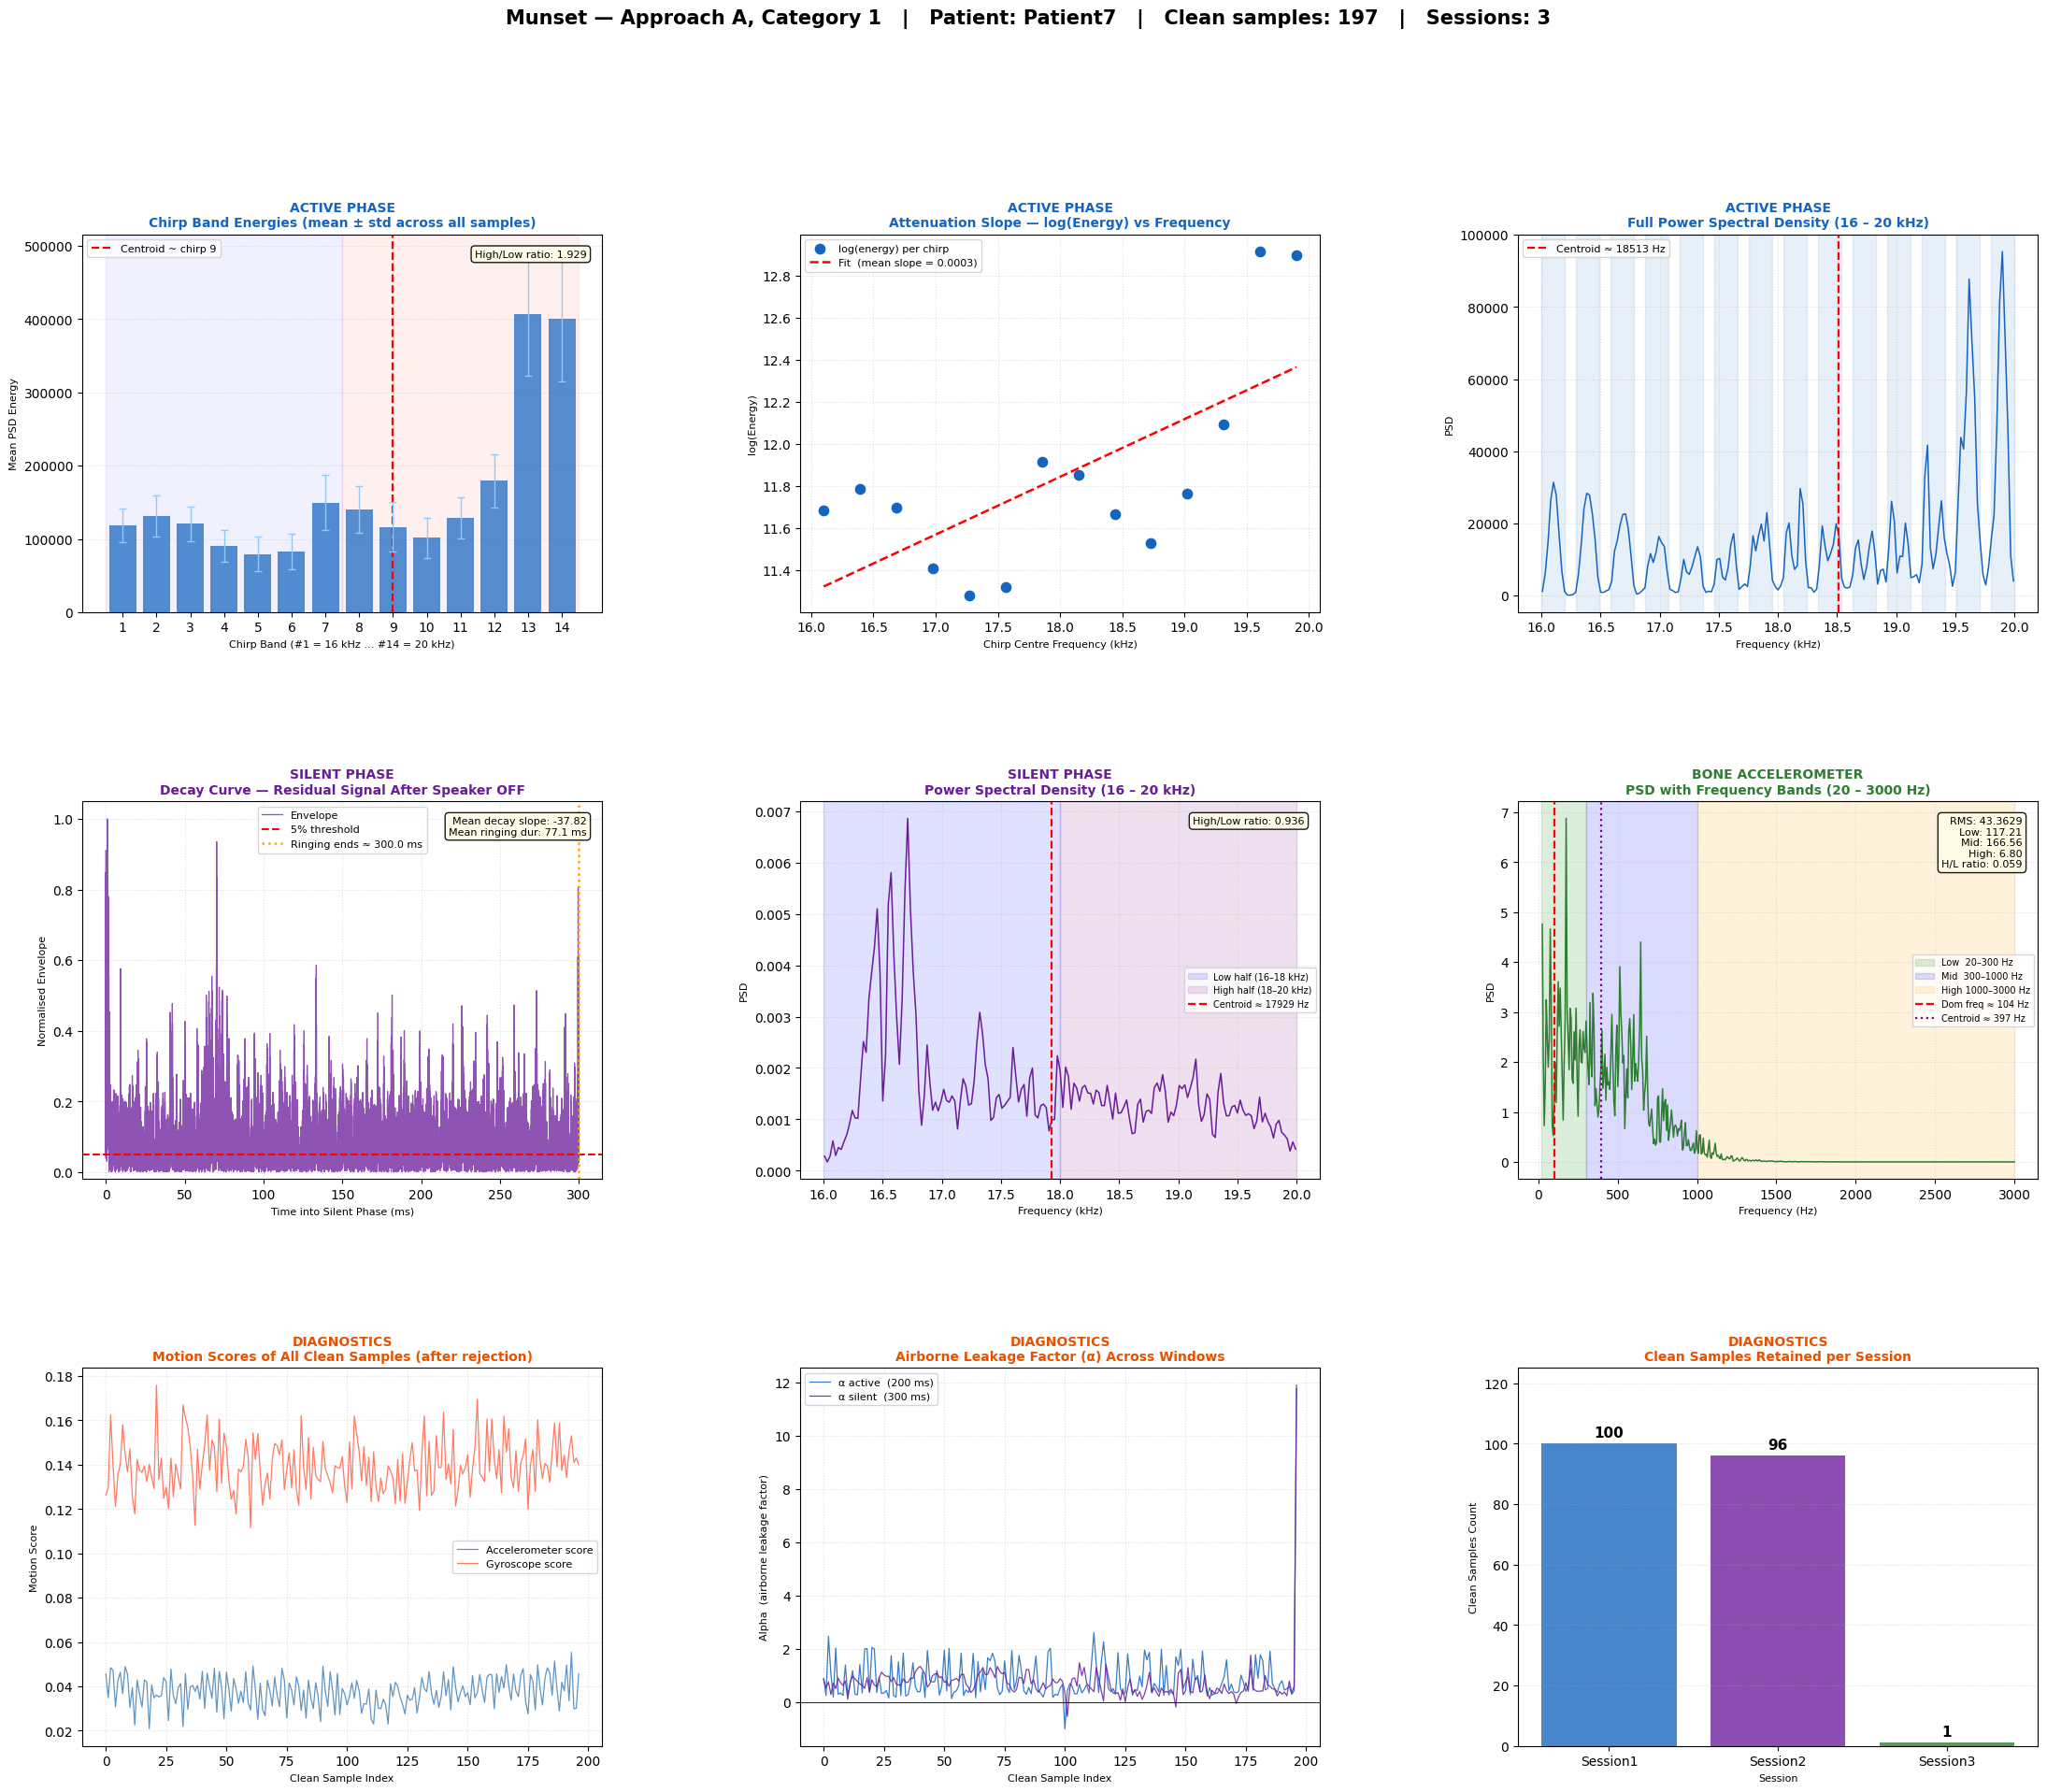


✅ Visualization saved → /content/drive/MyDrive/Munset/Data/Patient7/Result/Patient7_A1_feature_visualization.png


In [ ]:
# ================================================================
# PATIENT FEATURE VISUALIZATION
# Produces one large figure covering every feature and diagnostic.
# Saved to:  {RESULT_PATH}/{PATIENT_ID}_A1_feature_visualization.png
# ================================================================

import matplotlib.gridspec as gridspec

# ----------------------------------------------------------------
# A. Re-process ONE representative sample for signal-level plots
#    (active PSD, silent PSD, decay curve, bone PSD)
#    We pick the clean sample whose acc_score is closest to the
#    median — i.e. the most "typical" clean sample.
# ----------------------------------------------------------------

# Find best session (most clean samples) and representative sample
session_counts_viz = feature_df.groupby('session_id')['sample_id'].count()
best_sid           = session_counts_viz.idxmax()
best_path          = [p for p in session_paths
                      if os.path.splitext(os.path.basename(p))[0] == best_sid][0]

ds_viz      = SensorDataset(best_path)
inward_viz  = ds_viz.audio_stereo[:, 0].astype(np.float64)
outward_viz = ds_viz.audio_stereo[:, 1].astype(np.float64)
acc_v       = ds_viz.imu.acc
gyro_v      = ds_viz.imu.gyro
bone_v      = ds_viz.bone_acc.to_dataframe()

ref_t = []
if not acc_v.empty:  ref_t.append(float(acc_v.index.min()))
if not gyro_v.empty: ref_t.append(float(gyro_v.index.min()))
if not bone_v.empty: ref_t.append(float(bone_v.index.min()))
t0_ref = min(ref_t) if ref_t else 0.0
if not acc_v.empty:  acc_v  = acc_v.copy();  acc_v.index  -= t0_ref
if not gyro_v.empty: gyro_v = gyro_v.copy(); gyro_v.index -= t0_ref
if not bone_v.empty: bone_v = bone_v.copy(); bone_v.index -= t0_ref

fs_bone_v = float(1.0 / np.median(np.diff(bone_v.index.values))) if len(bone_v) > 1 else 6400.0

sess_clean   = feature_df[feature_df['session_id'] == best_sid].copy()
med_acc      = sess_clean['acc_score'].median()
rep_row      = sess_clean.iloc[(sess_clean['acc_score'] - med_acc).abs().argsort()[:1]]
rep_sample   = int(rep_row['sample_id'].values[0])

# Use onset-based slicing — matches the pipeline exactly
all_onsets_viz = detect_all_chirp_onsets(inward_viz)
n_viz_onsets   = min(len(all_onsets_viz), 100)
rep_onset_idx  = min(rep_sample, n_viz_onsets - 1)
s_start        = all_onsets_viz[rep_onset_idx]

active_end_viz = min(s_start + ACTIVE_SAMPLES, len(inward_viz))
if rep_onset_idx + 1 < len(all_onsets_viz):
    silent_end_viz = all_onsets_viz[rep_onset_idx + 1]
else:
    silent_end_viz = s_start + WINDOW_SAMPLES
silent_end_viz = min(silent_end_viz, len(inward_viz))

inw_a = inward_viz [s_start        : active_end_viz]
inw_s = inward_viz [active_end_viz : silent_end_viz]
out_a = outward_viz[s_start        : active_end_viz]
out_s = outward_viz[active_end_viz : silent_end_viz]

t_lo = s_start        / FS_MIC
t_hi = silent_end_viz / FS_MIC
bone_win_v = (bone_v[(bone_v.index >= t_lo) & (bone_v.index < t_hi)]
              if not bone_v.empty else pd.DataFrame(columns=['x','y','z']))

bone_a_sig, _ = remove_airborne(inw_a, out_a)
bone_s_sig, _ = remove_airborne(inw_s, out_s)
active_sig     = bandpass_16_20k(bone_a_sig)
silent_sig     = bandpass_16_20k(bone_s_sig)

# Bone accelerometer signal
if not bone_win_v.empty and len(bone_win_v) >= 10:
    bx = bone_win_v['x'].values.astype(float)
    by = bone_win_v['y'].values.astype(float)
    bz = bone_win_v['z'].values.astype(float)
    bone_mag_v = np.sqrt(bx**2 + by**2 + bz**2)
    bone_mag_v = bone_mag_v - np.mean(bone_mag_v)
    try:
        bone_filt_v = bandpass_bone(bone_mag_v, fs_bone_v)
    except Exception:
        bone_filt_v = None
else:
    bone_filt_v = None

# ----------------------------------------------------------------
# B. Aggregate feature values across ALL clean samples
# ----------------------------------------------------------------
chirp_cols    = [f'active_chirp_{i+1:02d}_energy' for i in range(N_CHIRPS)]
chirp_means   = feature_df[chirp_cols].mean().values
chirp_stds    = feature_df[chirp_cols].std().values
chirp_centers = np.array([
    CHIRP_START + i * (CHIRP_BW + GUARD_BW) + CHIRP_BW / 2
    for i in range(N_CHIRPS)
])

def _mean(col):
    return feature_df[col].mean() if col in feature_df.columns else np.nan

m_slope    = _mean('active_attenuation_slope')
m_hl       = _mean('active_high_low_ratio')
m_cent     = _mean('active_spectral_centroid')
m_decay    = _mean('silent_decay_slope')
m_ring     = _mean('silent_ringing_duration_ms')
m_s_hl     = _mean('silent_silent_high_low_ratio')
m_s_cent   = _mean('silent_silent_spectral_centroid')
m_b_rms    = _mean('bone_rms')
m_b_dom    = _mean('bone_dom_freq')
m_b_cent   = _mean('bone_spectral_centroid')
m_b_low    = _mean('bone_low_power')
m_b_mid    = _mean('bone_mid_power')
m_b_high   = _mean('bone_high_power')
m_b_hl     = _mean('bone_high_low_ratio')

# ----------------------------------------------------------------
# C. Build the figure  (3 rows × 3 columns)
# ----------------------------------------------------------------
C_ACT  = '#1565C0'   # deep blue   — active phase
C_SIL  = '#6A1B9A'   # deep purple — silent phase
C_BONE = '#2E7D32'   # deep green  — bone accelerometer
C_DIAG = '#E65100'   # deep orange — diagnostics

fig = plt.figure(figsize=(27, 21))
fig.patch.set_facecolor('white')

n_clean   = len(feature_df)
n_sess    = feature_df['session_id'].nunique()
fig.suptitle(
    f'Munset — Approach A, Category 1   |   Patient: {PATIENT_ID}   |   ' +
    f'Clean samples: {n_clean}   |   Sessions: {n_sess}',
    fontsize=15, fontweight='bold', y=0.995
)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

# ── helpers ──────────────────────────────────────────────────────
def _box(ax, txt, color):
    ax.text(0.97, 0.96, txt, transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='#FFFDE7', alpha=0.9))

def _title(ax, section, subtitle, color):
    ax.set_title(f'{section}\n{subtitle}', fontsize=10,
                 fontweight='bold', color=color, pad=6)

# ════════════════════════════════════════════════════════════════
# PLOT 1 — Active: Chirp Band Energies
# ════════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0, 0])
x_pos = np.arange(1, N_CHIRPS + 1)
ax1.bar(x_pos, chirp_means, yerr=chirp_stds,
        color=C_ACT, alpha=0.72, capsize=3,
        error_kw={'linewidth': 1, 'ecolor': '#90CAF9'}, zorder=2)
# shade low vs high halves
ax1.axvspan(0.5, 7.5,  alpha=0.06, color='blue')
ax1.axvspan(7.5, 14.5, alpha=0.06, color='red')
# annotate centroid chirp position (nearest centre)
if not np.isnan(m_cent):
    dists   = np.abs(chirp_centers - m_cent)
    c_idx   = int(np.argmin(dists)) + 1
    ax1.axvline(x=c_idx, color='red', linestyle='--',
                linewidth=1.6, label=f'Centroid ~ chirp {c_idx}')
    ax1.legend(fontsize=8)
ax1.set_xlabel('Chirp Band (#1 = 16 kHz … #14 = 20 kHz)', fontsize=8)
ax1.set_ylabel('Mean PSD Energy', fontsize=8)
ax1.set_xticks(x_pos)
ax1.grid(axis='y', linestyle=':', alpha=0.4)
_title(ax1, 'ACTIVE PHASE', 'Chirp Band Energies (mean ± std across all samples)', C_ACT)
_box(ax1, f'High/Low ratio: {m_hl:.3f}', C_ACT)

# ════════════════════════════════════════════════════════════════
# PLOT 2 — Active: Attenuation Slope
# ════════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[0, 1])
log_e = np.log(chirp_means + 1e-12)
fit   = np.polyfit(chirp_centers / 1000, log_e, 1)
fit_y = np.polyval(fit, chirp_centers / 1000)
ax2.scatter(chirp_centers / 1000, log_e,
            color=C_ACT, s=55, zorder=3, label='log(energy) per chirp')
ax2.plot(chirp_centers / 1000, fit_y,
         color='red', linewidth=1.8, linestyle='--',
         label=f'Fit  (mean slope = {m_slope:.4f})')
ax2.set_xlabel('Chirp Centre Frequency (kHz)', fontsize=8)
ax2.set_ylabel('log(Energy)', fontsize=8)
ax2.legend(fontsize=8)
ax2.grid(linestyle=':', alpha=0.4)
_title(ax2, 'ACTIVE PHASE', 'Attenuation Slope — log(Energy) vs Frequency', C_ACT)

# ════════════════════════════════════════════════════════════════
# PLOT 3 — Active: Full PSD
# ════════════════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[0, 2])
fa, pa = welch(active_sig, fs=FS_MIC, nperseg=min(2048, len(active_sig)))
pa = pa + 1e-12
msk_a = (fa >= 16000) & (fa <= 20000)
ax3.plot(fa[msk_a] / 1000, pa[msk_a], color=C_ACT, linewidth=1.1)
# shade each chirp band lightly
for i in range(N_CHIRPS):
    f1 = (CHIRP_START + i * (CHIRP_BW + GUARD_BW)) / 1000
    f2 = f1 + CHIRP_BW / 1000
    ax3.axvspan(f1, f2, alpha=0.10, color=C_ACT)
if not np.isnan(m_cent):
    ax3.axvline(x=m_cent / 1000, color='red', linestyle='--',
                linewidth=1.6, label=f'Centroid ≈ {m_cent:.0f} Hz')
    ax3.legend(fontsize=8)
ax3.set_xlabel('Frequency (kHz)', fontsize=8)
ax3.set_ylabel('PSD', fontsize=8)
ax3.grid(linestyle=':', alpha=0.4)
_title(ax3, 'ACTIVE PHASE', 'Full Power Spectral Density (16 – 20 kHz)', C_ACT)

# ════════════════════════════════════════════════════════════════
# PLOT 4 — Silent: Decay Curve
# ════════════════════════════════════════════════════════════════
ax4 = fig.add_subplot(gs[1, 0])
env_raw  = np.abs(silent_sig)
env_peak = np.max(env_raw) if np.max(env_raw) > 1e-12 else 1.0
env_norm = env_raw / env_peak
t_ms     = np.arange(len(env_norm)) / FS_MIC * 1000
ax4.plot(t_ms, env_norm, color=C_SIL, linewidth=0.9, alpha=0.75, label='Envelope')
ax4.axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='5% threshold')
valid_t = t_ms[env_norm > 0.05]
if len(valid_t) > 0:
    ax4.axvline(x=valid_t[-1], color='orange', linestyle=':',
                linewidth=1.8, label=f'Ringing ends ≈ {valid_t[-1]:.1f} ms')
ax4.set_ylim(-0.02, 1.05)
ax4.set_xlabel('Time into Silent Phase (ms)', fontsize=8)
ax4.set_ylabel('Normalised Envelope', fontsize=8)
ax4.legend(fontsize=8)
ax4.grid(linestyle=':', alpha=0.4)
_title(ax4, 'SILENT PHASE', 'Decay Curve — Residual Signal After Speaker OFF', C_SIL)
_box(ax4, f'Mean decay slope: {m_decay:.2f}\nMean ringing dur: {m_ring:.1f} ms', C_SIL)

# ════════════════════════════════════════════════════════════════
# PLOT 5 — Silent: PSD
# ════════════════════════════════════════════════════════════════
ax5 = fig.add_subplot(gs[1, 1])
fs2, ps2 = welch(silent_sig, fs=FS_MIC, nperseg=min(2048, len(silent_sig)))
ps2 = ps2 + 1e-12
msk_s = (fs2 >= 16000) & (fs2 <= 20000)
ax5.plot(fs2[msk_s] / 1000, ps2[msk_s], color=C_SIL, linewidth=1.1)
ax5.axvspan(16, 18, alpha=0.12, color='blue',   label='Low half (16–18 kHz)')
ax5.axvspan(18, 20, alpha=0.12, color='purple', label='High half (18–20 kHz)')
if not np.isnan(m_s_cent):
    ax5.axvline(x=m_s_cent / 1000, color='red', linestyle='--',
                linewidth=1.6, label=f'Centroid ≈ {m_s_cent:.0f} Hz')
ax5.set_xlabel('Frequency (kHz)', fontsize=8)
ax5.set_ylabel('PSD', fontsize=8)
ax5.legend(fontsize=7)
ax5.grid(linestyle=':', alpha=0.4)
_title(ax5, 'SILENT PHASE', 'Power Spectral Density (16 – 20 kHz)', C_SIL)
_box(ax5, f'High/Low ratio: {m_s_hl:.3f}', C_SIL)

# ════════════════════════════════════════════════════════════════
# PLOT 6 — Bone Accelerometer: PSD with bands
# ════════════════════════════════════════════════════════════════
ax6 = fig.add_subplot(gs[1, 2])
if bone_filt_v is not None and len(bone_filt_v) > 10:
    npb = min(1024, len(bone_filt_v))
    fb, pb = welch(bone_filt_v, fs=fs_bone_v, nperseg=npb)
    pb = pb + 1e-12
    msk_b = (fb >= 20) & (fb <= 3000)
    ax6.plot(fb[msk_b], pb[msk_b], color=C_BONE, linewidth=1.1)
    ax6.axvspan(20,   300,  alpha=0.14, color='green',  label='Low  20–300 Hz')
    ax6.axvspan(300,  1000, alpha=0.14, color='blue',   label='Mid  300–1000 Hz')
    ax6.axvspan(1000, 3000, alpha=0.14, color='orange', label='High 1000–3000 Hz')
    if not np.isnan(m_b_dom):
        ax6.axvline(x=m_b_dom, color='red', linestyle='--',
                    linewidth=1.6, label=f'Dom freq ≈ {m_b_dom:.0f} Hz')
    if not np.isnan(m_b_cent):
        ax6.axvline(x=m_b_cent, color='purple', linestyle=':',
                    linewidth=1.6, label=f'Centroid ≈ {m_b_cent:.0f} Hz')
    ax6.legend(fontsize=7)
    note = (f'RMS: {m_b_rms:.4f}\n'
            f'Low: {m_b_low:.2f}\n'
            f'Mid: {m_b_mid:.2f}\n'
            f'High: {m_b_high:.2f}\n'
            f'H/L ratio: {m_b_hl:.3f}')
    _box(ax6, note, C_BONE)
else:
    ax6.text(0.5, 0.5, 'No bone accelerometer data available',
             ha='center', va='center', transform=ax6.transAxes, fontsize=10)
ax6.set_xlabel('Frequency (Hz)', fontsize=8)
ax6.set_ylabel('PSD', fontsize=8)
ax6.grid(linestyle=':', alpha=0.4)
_title(ax6, 'BONE ACCELEROMETER', 'PSD with Frequency Bands (20 – 3000 Hz)', C_BONE)

# ════════════════════════════════════════════════════════════════
# PLOT 7 — Diagnostics: Motion Scores
# ════════════════════════════════════════════════════════════════
ax7 = fig.add_subplot(gs[2, 0])
idx_s   = np.arange(len(feature_df))
acc_sc  = feature_df['acc_score'].values
gyro_sc = feature_df['gyro_score'].values
ax7.plot(idx_s, acc_sc,  color='steelblue', linewidth=0.9, alpha=0.85, label='Accelerometer score')
ax7.plot(idx_s, gyro_sc, color='tomato',    linewidth=0.9, alpha=0.85, label='Gyroscope score')
ax7.set_xlabel('Clean Sample Index', fontsize=8)
ax7.set_ylabel('Motion Score', fontsize=8)
ax7.legend(fontsize=8)
ax7.grid(linestyle=':', alpha=0.4)
_title(ax7, 'DIAGNOSTICS', 'Motion Scores of All Clean Samples (after rejection)', C_DIAG)

# ════════════════════════════════════════════════════════════════
# PLOT 8 — Diagnostics: Alpha (airborne leakage factor)
# ════════════════════════════════════════════════════════════════
ax8 = fig.add_subplot(gs[2, 1])
al_act = feature_df['alpha_active'].values
al_sil = feature_df['alpha_silent'].values
ax8.plot(idx_s, al_act, color=C_ACT,  linewidth=0.9, alpha=0.85, label='α active  (200 ms)')
ax8.plot(idx_s, al_sil, color=C_SIL,  linewidth=0.9, alpha=0.85, label='α silent  (300 ms)')
ax8.axhline(y=0, color='black', linewidth=0.6, linestyle='-')
ax8.set_xlabel('Clean Sample Index', fontsize=8)
ax8.set_ylabel('Alpha  (airborne leakage factor)', fontsize=8)
ax8.legend(fontsize=8)
ax8.grid(linestyle=':', alpha=0.4)
_title(ax8, 'DIAGNOSTICS', 'Airborne Leakage Factor (α) Across Windows', C_DIAG)

# ════════════════════════════════════════════════════════════════
# PLOT 9 — Diagnostics: Clean samples per session
# ════════════════════════════════════════════════════════════════
ax9 = fig.add_subplot(gs[2, 2])
s_counts = feature_df.groupby('session_id')['sample_id'].count()
bar_cols  = ([C_ACT, C_SIL, C_BONE, C_DIAG] * 2)[:len(s_counts)]
bars9 = ax9.bar(s_counts.index, s_counts.values, color=bar_cols, alpha=0.78)
ax9.bar_label(bars9, fmt='%d', fontsize=11, fontweight='bold', padding=3)
ax9.set_xlabel('Session', fontsize=8)
ax9.set_ylabel('Clean Samples Count', fontsize=8)
ax9.set_ylim(0, max(s_counts.values) * 1.25)
ax9.grid(axis='y', linestyle=':', alpha=0.4)
_title(ax9, 'DIAGNOSTICS', 'Clean Samples Retained per Session', C_DIAG)

# ────────────────────────────────────────────────────────────────
# Save
# ────────────────────────────────────────────────────────────────
viz_path = os.path.join(RESULT_PATH, f'{PATIENT_ID}_A1_feature_visualization.png')
fig.savefig(viz_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'\n✅ Visualization saved → {viz_path}')

## Combined Visualization

In [ ]:
# ================================================================
# CELL 1 — Collect signals from all patients
# Re-runs preprocessing pipeline to get PSDs and decay envelopes.
# ⚠️  Takes several minutes. Run once, then use Cell 2 to plot.
# ================================================================

import glob
import matplotlib.lines as mlines
from matplotlib.patches import Patch

PATIENT_GROUPS = {
    'Patient1': 'Osteoporosis',
    'Patient2': 'Healthy',
    'Patient3': 'Osteoporosis',
    'Patient4': 'Healthy',
    'Patient6': 'Osteoporosis',
    'Patient7': 'Osteoporosis',
}

COLOR_OSTEO   = '#c0392b'
COLOR_HEALTHY = '#27ae60'
def pcolor(group): return COLOR_OSTEO if group == 'Osteoporosis' else COLOR_HEALTHY

# ---- Save original PATIENT_ID so we can restore it ----------
_original_patient_id = PATIENT_ID

def collect_patient_signals(patient_id, group):
    global PATIENT_ID
    PATIENT_ID = patient_id

    right_ear = (f"/content/drive/MyDrive/Munset/Data/"
                 f"{patient_id}/Right_Ear")
    oe_files  = sorted(glob.glob(os.path.join(right_ear, '*.oe')))

    if not oe_files:
        print(f"  ⚠️  No .oe files found"); return None

    active_psds, chirp_energy_all = [], []
    silent_envelopes, silent_psds  = [], []
    bone_psd_all                   = []
    freqs_active = freqs_bone = None
    chirp_centres_ref = None

    for oe_path in oe_files:
        sid = os.path.splitext(os.path.basename(oe_path))[0]
        print(f"  {sid}", end=' ... ')
        try:
            # --- Steps 1–2: Load and extract streams ---
            ds          = SensorDataset(oe_path)
            audio       = ds.audio_stereo
            inward_raw  = audio[:, 0].astype(float)
            outward_raw = audio[:, 1].astype(float)

            acc_df  = ds.imu.acc
            gyro_df = ds.imu.gyro
            bone_df = (ds.bone_acc.to_dataframe()
                       if ds.bone_acc is not None
                       else pd.DataFrame(columns=['x','y','z']))

            # Normalise timestamps
            t0_vals = []
            for df in [acc_df, gyro_df, bone_df]:
                if not df.empty: t0_vals.append(df.index.min())
            if t0_vals:
                t0 = min(t0_vals)
                for df in [acc_df, gyro_df, bone_df]:
                    if not df.empty: df.index = df.index - t0

            fs_bone = (1.0 / float(np.median(np.diff(bone_df.index.values)))
                       if len(bone_df) > 1 else 6400.0)

            # --- Step 3: Detect onsets ---
            onsets   = detect_all_chirp_onsets(inward_raw)
            drop_set = set(WINDOWS_TO_DROP.get(PATIENT_ID, []))
            onsets   = [o for i, o in enumerate(onsets) if i not in drop_set]
            n_win    = min(len(onsets), 100)
            if n_win == 0: print("no windows"); continue

            # --- Steps 4–5: Build windows ---
            raw_samples = []
            for i in range(n_win):
                start      = onsets[i]
                active_end = min(start + ACTIVE_SAMPLES, len(inward_raw))
                silent_end = min(
                    onsets[i+1] if i+1 < len(onsets) else start + WINDOW_SAMPLES,
                    len(inward_raw))
                t0_w, t1_w = start / FS_MIC, silent_end / FS_MIC

                def slice_df(df, t0, t1):
                    return (df[(df.index >= t0) & (df.index < t1)]
                            if not df.empty
                            else pd.DataFrame(columns=['x','y','z']))

                s = {
                    'inw_a': inward_raw [start:active_end],
                    'inw_s': inward_raw [active_end:silent_end],
                    'out_a': outward_raw[start:active_end],
                    'out_s': outward_raw[active_end:silent_end],
                    'acc'  : slice_df(acc_df,  t0_w, t1_w),
                    'gyro' : slice_df(gyro_df, t0_w, t1_w),
                    'bone' : slice_df(bone_df, t0_w, t1_w),
                }
                s['acc_score'], s['gyro_score'] = compute_motion_scores(
                    s['acc'], s['gyro'])
                raw_samples.append(s)

            # --- Steps 6–7: Motion rejection ---
            t_acc  = mad_threshold([s['acc_score']  for s in raw_samples])
            t_gyro = mad_threshold([s['gyro_score'] for s in raw_samples])
            clean  = [s for s in raw_samples
                      if (np.isnan(s['acc_score'])  or s['acc_score']  <= t_acc)
                      and (np.isnan(s['gyro_score']) or s['gyro_score'] <= t_gyro)]
            if not clean: print("0 clean"); continue

            # --- Steps 8–9: Airborne removal + bandpass ---
            for s in clean:
                s['x_a'], _ = remove_airborne(s['inw_a'], s['out_a'])
                s['x_s'], _ = remove_airborne(s['inw_s'], s['out_s'])
                s['x_a']    = bandpass_16_20k(s['x_a'])
                s['x_s']    = bandpass_16_20k(s['x_s'])

            # --- Collect signals ---
            for s in clean:
                # Active PSD
                fa, pa = welch(s['x_a'], fs=FS_MIC,
                               nperseg=min(2048, len(s['x_a'])))
                active_psds.append(pa)
                if freqs_active is None: freqs_active = fa

                # Chirp energies
                energies, centres = [], []
                for i in range(N_CHIRPS):
                    f1 = CHIRP_START + i*(CHIRP_BW + GUARD_BW)
                    f2, fc = f1 + CHIRP_BW, (f1 + f1 + CHIRP_BW)/2
                    energies.append(float(np.sum(pa[(fa >= f1) & (fa < f2)])))
                    centres.append(fc)
                chirp_energy_all.append(energies)
                if chirp_centres_ref is None:
                    chirp_centres_ref = np.array(centres)

                # Silent envelope
                env = np.abs(s['x_s'])
                mx  = np.max(env)
                if mx > 1e-12:
                    silent_envelopes.append(env / mx)

                # Silent PSD
                _, ps = welch(s['x_s'], fs=FS_MIC,
                              nperseg=min(2048, len(s['x_s'])))
                silent_psds.append(ps)

                # Bone PSD
                bw = s['bone']
                if not bw.empty and len(bw) >= 10:
                    try:
                        bmag = np.sqrt(
                            bw['x'].values.astype(float)**2 +
                            bw['y'].values.astype(float)**2 +
                            bw['z'].values.astype(float)**2)
                        bmag -= bmag.mean()
                        bf   = bandpass_bone(bmag, fs_bone)
                        fb, pb = welch(bf, fs=fs_bone,
                                       nperseg=min(1024, len(bf)))
                        mask = (fb >= 20) & (fb <= 3000)
                        bone_psd_all.append(pb[mask])
                        if freqs_bone is None: freqs_bone = fb[mask]
                    except:
                        pass

            print(f"{len(clean)} clean")

        except Exception as e:
            print(f"ERROR — {e}")
            continue

    if not active_psds:
        print(f"  ⚠️  No usable data for {patient_id}"); return None

    # Align arrays to minimum length
    n_a = min(len(p) for p in active_psds)
    n_s = min(len(p) for p in silent_psds)
    n_e = min(len(e) for e in silent_envelopes) if silent_envelopes else 0
    n_b = min(len(b) for b in bone_psd_all)     if bone_psd_all     else 0

    return {
        'patient_id'         : patient_id,
        'group'              : group,
        'freqs_active'       : freqs_active[:n_a],
        'active_psd_mean'    : np.mean([p[:n_a] for p in active_psds],     axis=0),
        'active_psd_std'     : np.std( [p[:n_a] for p in active_psds],     axis=0),
        'chirp_energies_mean': np.mean(chirp_energy_all, axis=0),
        'chirp_energies_std' : np.std( chirp_energy_all, axis=0),
        'chirp_centres'      : chirp_centres_ref,
        'freqs_silent'       : freqs_active[:n_s],
        'silent_psd_mean'    : np.mean([p[:n_s] for p in silent_psds],     axis=0),
        'silent_psd_std'     : np.std( [p[:n_s] for p in silent_psds],     axis=0),
        'env_t_ms'           : np.arange(n_e) / FS_MIC * 1000,
        'silent_env_mean'    : (np.mean([e[:n_e] for e in silent_envelopes], axis=0)
                                if silent_envelopes else None),
        'freqs_bone'         : freqs_bone[:n_b] if freqs_bone is not None else None,
        'bone_psd_mean'      : (np.mean([b[:n_b] for b in bone_psd_all], axis=0)
                                if bone_psd_all else None),
        'bone_psd_std'       : (np.std( [b[:n_b] for b in bone_psd_all], axis=0)
                                if bone_psd_all else None),
    }


# ---- Run ---------------------------------------------------
print("Processing all patients — please wait...\n")
patient_data = {}
for pid, grp in PATIENT_GROUPS.items():
    print(f"\n[{pid}  |  {grp}]")
    result = collect_patient_signals(pid, grp)
    if result: patient_data[pid] = result

PATIENT_ID = _original_patient_id   # restore original
print(f"\n✅  Done — {len(patient_data)} patients collected")

Processing all patients — please wait...


[Patient1  |  Osteoporosis]
  Session1 ...   📂 Session1.oe  ver=2  t0=1779045482259520µs
97 clean
  Session2 ...   📂 Session2.oe  ver=2  t0=1779045601952957µs
97 clean
  Session3 ...   📂 Session3.oe  ver=2  t0=1779045697908806µs
96 clean

[Patient2  |  Healthy]
  Session1 ...   📂 Session1.oe  ver=2  t0=1779412356040605µs
86 clean
  Session2 ...   📂 Session2.oe  ver=2  t0=1779412451668435µs
92 clean
  Session3 ...   📂 Session3.oe  ver=2  t0=1779412783378654µs
90 clean
  Session4 ...   📂 Session4.oe  ver=2  t0=1779412866692753µs
93 clean

[Patient3  |  Osteoporosis]
  Session1 ...   📂 Session1.oe  ver=2  t0=1779126295566874µs
82 clean
  Session2 ...   📂 Session2.oe  ver=2  t0=1779126376641886µs
93 clean

[Patient4  |  Healthy]
  Session1 ...   📂 Session1.oe  ver=2  t0=1779110707549191µs
99 clean
  Session2 ...   📂 Session2.oe  ver=2  t0=1779110850451932µs
97 clean
  Session3 ...   📂 Session3.oe  ver=2  t0=1779110930288785µs
98 clean
  Session4 .

✅ Saved → /content/drive/MyDrive/Munset/Data/All_Patients_A1_signal_comparison.png


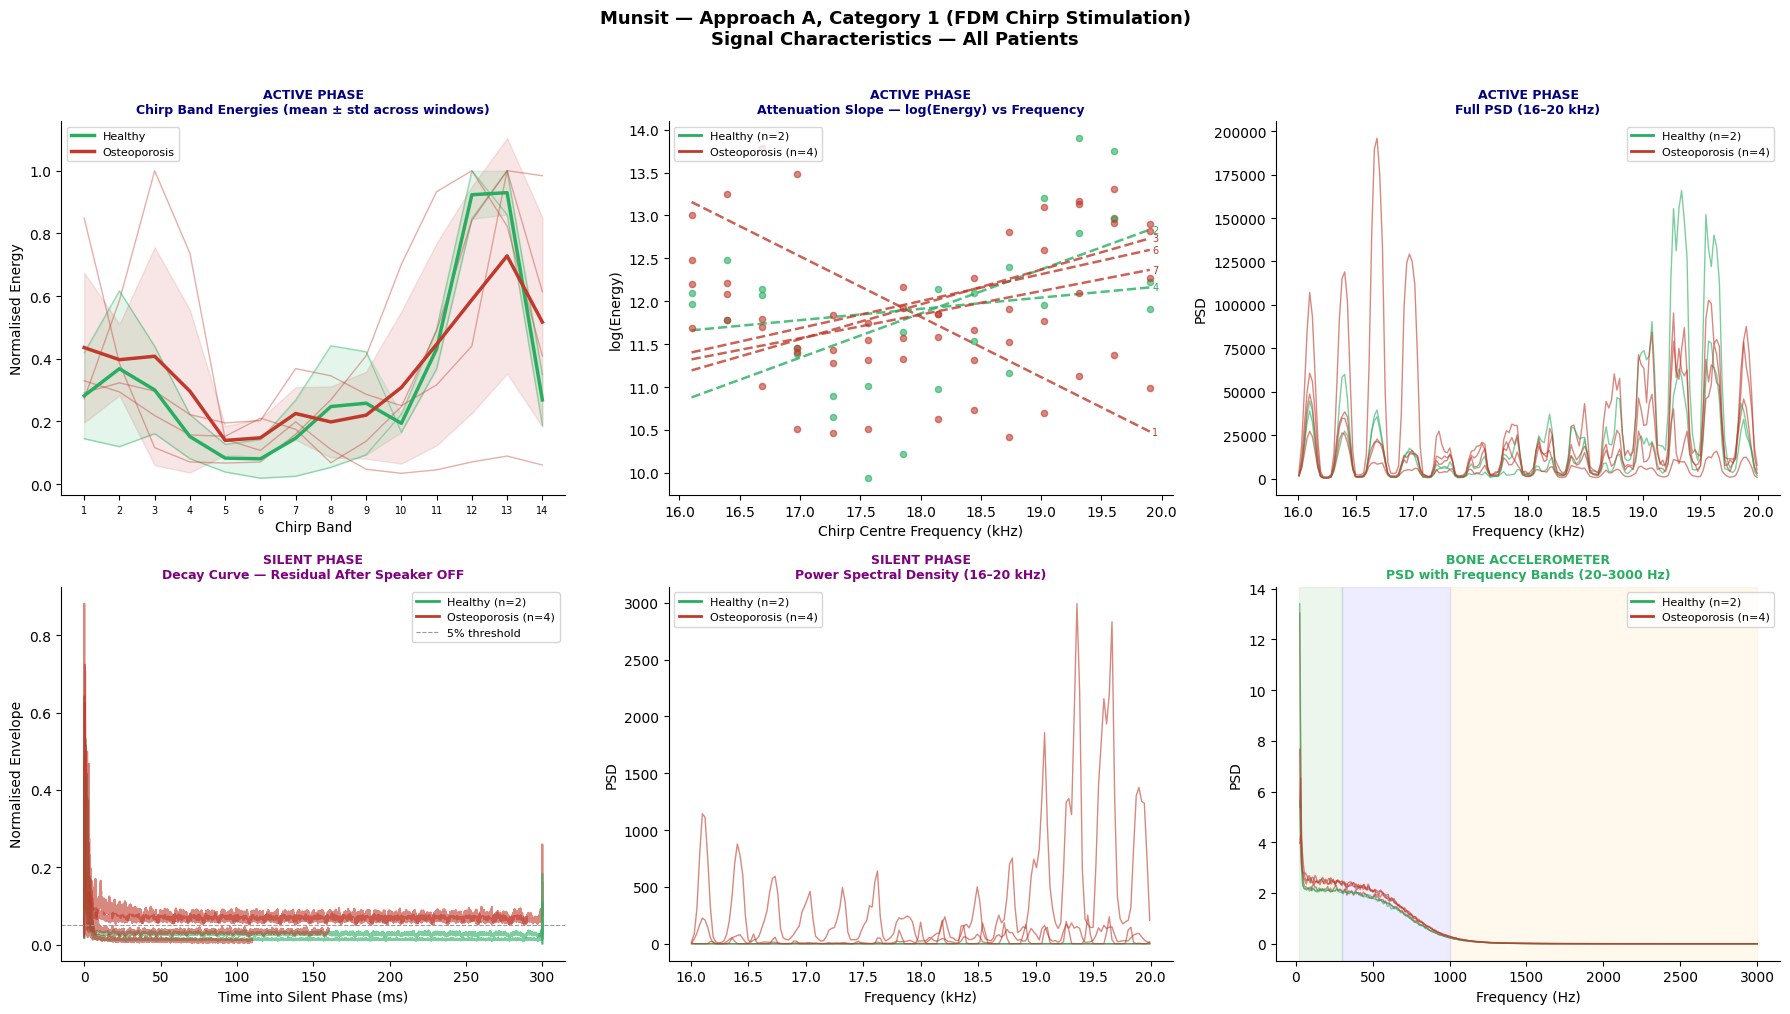


Per-Patient Feature Summary — Approach A, Category 1


,Group,Attn. Slope,Active H/L,Spectral Centroid,Decay Slope,Ringing Dur. (ms),Silent H/L,Bone RMS,Dom. Freq. (Hz),Bone H/L
Patient,,,,,,,,,,
Patient1,Osteoporosis,-0.70406,0.1507,17070.9356,-5.2249,132.7897,1.0384,44.0222,51.8101,0.0552
Patient2,Healthy,0.51452,4.9394,18852.2436,-96.9204,18.8583,1.4479,41.1654,32.5988,0.0511
Patient3,Osteoporosis,0.40496,2.6476,18406.2433,-4.2303,190.5417,1.0870,40.5613,112.1255,0.0555
Patient4,Healthy,0.13158,1.6086,18236.5420,-139.5586,53.8841,0.8918,39.9631,124.8275,0.0588
Patient6,Osteoporosis,0.31443,2.2100,18571.4823,-269.4728,9.4291,1.3604,43.1924,144.0053,0.0595
Patient7,Osteoporosis,0.27453,1.9080,18512.5210,-37.8203,77.1433,0.9360,43.3629,103.8004,0.0585


In [ ]:
# ================================================================
# CELL 2 — Plot 2×3 figure (same layout as per-patient plots)
# ================================================================

import matplotlib.lines as mlines
from matplotlib.patches import Patch
from IPython.display import display

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'Munsit — Approach A, Category 1 (FDM Chirp Stimulation)\n'
    'Signal Characteristics — All Patients',
    fontsize=13, fontweight='bold', y=1.01
)

chirp_nums = np.arange(1, N_CHIRPS + 1)

# ================================================================
# PANEL 1 — Chirp Band Energies
# ================================================================
ax = axes[0][0]

for pid, d in patient_data.items():
    e     = d['chirp_energies_mean']
    e_n   = e / (np.max(e) + 1e-12)
    ax.plot(chirp_nums, e_n, color=pcolor(d['group']),
            linewidth=1.0, alpha=0.4)

for grp, col in [('Healthy', COLOR_HEALTHY), ('Osteoporosis', COLOR_OSTEO)]:
    gd = [d for d in patient_data.values() if d['group'] == grp]
    if not gd: continue
    mat = np.array([d['chirp_energies_mean'] / (np.max(d['chirp_energies_mean'])+1e-12)
                    for d in gd])
    mn, sd = mat.mean(0), mat.std(0)
    ax.plot(chirp_nums, mn, color=col, linewidth=2.5, label=grp)
    ax.fill_between(chirp_nums, mn-sd, mn+sd, color=col, alpha=0.12)

ax.set_xlabel('Chirp Band');  ax.set_ylabel('Normalised Energy')
ax.set_title('ACTIVE PHASE\nChirp Band Energies (mean ± std across windows)',
             fontsize=9, fontweight='bold', color='navy')
ax.set_xticks(chirp_nums)
ax.set_xticklabels([str(i) for i in chirp_nums], fontsize=7)
ax.legend(fontsize=8, frameon=True, loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ================================================================
# PANEL 2 — Attenuation Slope
# ================================================================
ax = axes[0][1]

for pid, d in patient_data.items():
    col  = pcolor(d['group'])
    cx   = d['chirp_centres'] / 1000
    loge = np.log(d['chirp_energies_mean'] + 1e-12)
    ax.scatter(cx, loge, color=col, s=20, alpha=0.6, zorder=3)
    slope, intercept, *_ = linregress(cx, loge)
    xl = np.array([cx.min(), cx.max()])
    ax.plot(xl, slope*xl + intercept, color=col,
            linewidth=1.8, linestyle='--', alpha=0.8)
    ax.text(cx.max() + 0.02, slope*cx.max() + intercept,
            f'{pid[-1]}', fontsize=7, color=col, va='center')

ax.set_xlabel('Chirp Centre Frequency (kHz)')
ax.set_ylabel('log(Energy)')
ax.set_title('ACTIVE PHASE\nAttenuation Slope — log(Energy) vs Frequency',
             fontsize=9, fontweight='bold', color='navy')
ax.legend(handles=[
    mlines.Line2D([], [], color=COLOR_HEALTHY, linewidth=2.0, label='Healthy (n=2)'),
    mlines.Line2D([], [], color=COLOR_OSTEO,   linewidth=2.0, label='Osteoporosis (n=4)'),
], fontsize=8, frameon=True, loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ================================================================
# PANEL 3 — Full Active Phase PSD
# ================================================================
ax = axes[0][2]

for pid, d in patient_data.items():
    f = d['freqs_active'] / 1000
    m = (f >= 16) & (f <= 20)
    ax.plot(f[m], d['active_psd_mean'][m],
            color=pcolor(d['group']), linewidth=1.0, alpha=0.6)

ax.set_xlabel('Frequency (kHz)');  ax.set_ylabel('PSD')
ax.set_title('ACTIVE PHASE\nFull PSD (16–20 kHz)',
             fontsize=9, fontweight='bold', color='navy')
ax.legend(handles=[
    mlines.Line2D([], [], color=COLOR_HEALTHY, linewidth=2.0, label='Healthy (n=2)'),
    mlines.Line2D([], [], color=COLOR_OSTEO,   linewidth=2.0, label='Osteoporosis (n=4)'),
], fontsize=8, frameon=True, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ================================================================
# PANEL 4 — Silent Phase Decay Curve
# ================================================================
ax = axes[1][0]

for pid, d in patient_data.items():
    if d['silent_env_mean'] is None: continue
    ax.plot(d['env_t_ms'], d['silent_env_mean'],
            color=pcolor(d['group']), linewidth=1.5, alpha=0.6)

ax.axhline(0.05, color='#999', linewidth=0.8, linestyle='--')
ax.set_xlabel('Time into Silent Phase (ms)')
ax.set_ylabel('Normalised Envelope')
ax.set_title('SILENT PHASE\nDecay Curve — Residual After Speaker OFF',
             fontsize=9, fontweight='bold', color='purple')
ax.legend(handles=[
    mlines.Line2D([], [], color=COLOR_HEALTHY, linewidth=2.0, label='Healthy (n=2)'),
    mlines.Line2D([], [], color=COLOR_OSTEO,   linewidth=2.0, label='Osteoporosis (n=4)'),
    mlines.Line2D([], [], color='#999', linewidth=0.8,
                  linestyle='--', label='5% threshold'),
], fontsize=8, frameon=True, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ================================================================
# PANEL 5 — Silent Phase PSD
# ================================================================
ax = axes[1][1]

for pid, d in patient_data.items():
    f = d['freqs_silent'] / 1000
    m = (f >= 16) & (f <= 20)
    ax.plot(f[m], d['silent_psd_mean'][m],
            color=pcolor(d['group']), linewidth=1.0, alpha=0.6)

ax.set_xlabel('Frequency (kHz)');  ax.set_ylabel('PSD')
ax.set_title('SILENT PHASE\nPower Spectral Density (16–20 kHz)',
             fontsize=9, fontweight='bold', color='purple')
ax.legend(handles=[
    mlines.Line2D([], [], color=COLOR_HEALTHY, linewidth=2.0, label='Healthy (n=2)'),
    mlines.Line2D([], [], color=COLOR_OSTEO,   linewidth=2.0, label='Osteoporosis (n=4)'),
], fontsize=8, frameon=True, loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ================================================================
# PANEL 6 — Bone Accelerometer PSD
# ================================================================
ax = axes[1][2]

for pid, d in patient_data.items():
    if d['bone_psd_mean'] is None or d['freqs_bone'] is None: continue
    ax.plot(d['freqs_bone'], d['bone_psd_mean'],
            color=pcolor(d['group']), linewidth=1.0, alpha=0.6)

ax.axvspan(20,    300,  alpha=0.07, color='green')
ax.axvspan(300,  1000,  alpha=0.07, color='blue')
ax.axvspan(1000, 3000,  alpha=0.07, color='orange')
ax.set_xlabel('Frequency (Hz)');  ax.set_ylabel('PSD')
ax.set_title('BONE ACCELEROMETER\nPSD with Frequency Bands (20–3000 Hz)',
             fontsize=9, fontweight='bold', color='#27ae60')
ax.legend(handles=[
    mlines.Line2D([], [], color=COLOR_HEALTHY, linewidth=2.0, label='Healthy (n=2)'),
    mlines.Line2D([], [], color=COLOR_OSTEO,   linewidth=2.0, label='Osteoporosis (n=4)'),
], fontsize=8, frameon=True, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ================================================================
# Figure legend
# ================================================================
# legend_handles = [
#     mlines.Line2D([], [], color=COLOR_HEALTHY, linewidth=2.5,
#                   label='Healthy  (n = 2)'),
#     mlines.Line2D([], [], color=COLOR_OSTEO,   linewidth=2.5,
#                   label='Osteoporosis  (n = 4)'),
#     mlines.Line2D([], [], color='gray', linewidth=1.0, alpha=0.5,
#                   label='Individual patient (thin line)'),
# ]
# fig.legend(handles=legend_handles, loc='upper right', fontsize=10,
#            frameon=True, title='Condition', title_fontsize=10,
#            bbox_to_anchor=(1.01, 1.01))

plt.tight_layout()

save_path = ("/content/drive/MyDrive/Munset/Data/"
             "All_Patients_A1_signal_comparison.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"✅ Saved → {save_path}")
plt.show()


# ================================================================
# NUMERICAL FEATURE SUMMARY — per-patient means
# ================================================================

print("\n" + "="*80)
print("Per-Patient Feature Summary — Approach A, Category 1")
print("="*80)

rows = []
for pid, grp in PATIENT_GROUPS.items():
    csv_path = (f"/content/drive/MyDrive/Munset/Data/"
                f"{pid}/Result/{pid}_A1_all_samples.csv")
    if not os.path.exists(csv_path):
        continue

    df  = pd.read_csv(csv_path)
    row = {'Patient': pid, 'Group': grp}

    # Attenuation slope and H/L ratio from patient_data
    if pid in patient_data:
        d  = patient_data[pid]
        e  = d['chirp_energies_mean']
        cx = d['chirp_centres'] / 1000
        slope, *_ = linregress(cx, np.log(e + 1e-12))
        row['Attn. Slope']   = round(float(slope), 5)
        row['Active H/L']    = round(float(
            np.sum(e[7:]) / (np.sum(e[:7]) + 1e-12)), 4)

    # Remaining scalar features from CSV
    feat_map = {
        'Spectral Centroid':  'active_spectral_centroid',
        'Decay Slope':        'silent_decay_slope',
        'Ringing Dur. (ms)':  'silent_ringing_duration_ms',
        'Silent H/L':         'silent_silent_high_low_ratio',
        'Bone RMS':           'bone_rms',
        'Dom. Freq. (Hz)':    'bone_dom_freq',
        'Bone H/L':           'bone_high_low_ratio',
    }
    for label, col in feat_map.items():
        if col in df.columns:
            row[label] = round(df[col].mean(skipna=True), 4)

    rows.append(row)

summary = pd.DataFrame(rows).set_index('Patient')
display(summary)